# Phase 1 — GENIE v19.0 Preprocessing & Alteration Matrix Construction

**Purpose**: this notebook does three things, not just one:
1. **Organize** the raw AACR GENIE public release into a single panel-aware
   alteration table (`data/processed/alterations_long.parquet`) that Phase 2+
   notebooks will use instead of the raw 1 GB MAF / 421 MB CNA files.
2. **Filter** the raw mutation calls down to the ones likely to actually
   matter for cancer: somatic only (not inherited), protein-changing only
   (not silent), uncommon in the healthy population (not a common germline
   polymorphism), and -- for missense calls -- backed by AlphaMissense
   and/or Polyphen+SIFT agreement, or a cancerhotspots.org recurrent-site
   match (Section 3c, the rule Jason approved) -- so what remains is
   likely-pathogenic mutations, not every raw variant call.
3. **Track testing coverage** by building `panel_gene_coverage.parquet` --
   recording exactly which gene was tested on which panel. Without this, a
   gene absent from a sample's results is ambiguous (never tested, or
   tested and clean?). Example: if gene X is only on a small panel used
   for 800 of 5,000 Lung Cancer samples, and 40 of those 800 show it
   altered, the true rate is 40/800 = 5% -- but treating all 5,000 as
   tested would wrongly give 40/5,000 = 0.8%, a number that just reflects
   which panel was used, not real biology. `panel_gene_coverage.parquet`
   is what lets Phase 2 always divide by the correct denominator (only
   samples actually tested for the gene(s) in question).

**Inputs**: `data/data_mutations_extended.txt`, `data/data_CNA.txt`,
`data/data_clinical_sample.txt`, `data/data_clinical_patient.txt`,
`data/genomic_information.txt`

**Outputs** (written to `data/processed/`):
- `clinical_tidy.parquet`
- `panel_gene_coverage.parquet`
- `alterations_long.parquet`
- `alphamissense_filtered.parquet` (cached AlphaMissense scores for our gene set)
- `putative_biallelic_tsg_events.parquet` (shallow-del + damaging-mutation two-hit TSG feature, external to `alterations_long`)
- `consensus_genes_global.parquet` (pooled-cohort gene list, for cross-cancer-type comparisons only)
- `consensus_genes_per_cancer_type.parquet` (per-cancer-type gene list, the one actually used for within-cancer-type work)
- `qc_summary.json`

This notebook is self-contained -- all loading/filtering logic is defined
in the cell below rather than imported from a separate script. See `PLAN.md`
for the full multi-phase project plan and the rationale for each filtering choice. Filter thresholds are provisional — flagged
for confirmation with the supervisor before Phase 2.

## Phase 1 data flow, at a glance

```text
data_clinical_sample.txt (271,837 rows)   data_clinical_patient.txt (227,696 rows)
   [1 row per SAMPLE]                            [1 row per PATIENT]
              \                                         /
               \----------  merge on PATIENT_ID  ------/
                                    |
                                    |  + TMB (tmb_19.0-public.tsv), trusted only on panels >= 1 Mb
                                    |    -> HYPERMUTATION_STATUS (Section 1b)
                                    |  + one representative sample per patient (Section 1c):
                                    |    has CNA data > primary tumour > larger panel
                                    v
                  clinical_tidy.parquet (271,837 rows, 227,696 flagged IS_REPRESENTATIVE)
     Purpose: attach cancer type + panel + survival to every sample, and
     make sure each patient is counted once downstream


genomic_information.txt (1,208,541 rows, 167 panels)
              |
              |  keep includeInPanel == True,
              |  collapse exon rows -> 1 row per (panel, gene)
              v
     panel_gene_coverage.parquet (53,291 (panel, gene) rows)
     Purpose: answer "was gene X tested on panel Y?" so a gene missing
     from a sample's results can be told apart as "not mutated" vs.
     "never tested" in the first place


data_CNA.txt  ->  which samples (and which genes) have copy-number data AT ALL
              |
              |  20 of the 48 panels whose metadata claims gene_level_cna
              |  have NO sample columns in data_CNA.txt; 16.2% of the
              |  mutation-covered (panel, gene) pairs have no CNA values
              v
     clinical_tidy.CNA_TESTED (172,874 samples)  +
     cna_gene_panel_coverage.parquet (11,680 (panel, gene) rows)
     Purpose: the denominator masks for anything copy-number related


data_mutations_extended.txt (3,458,550 rows)
              |
              |  1. Mutation_Status: keep "Somatic"/"SOMATIC" ...... 3,434,978 left
              |  2. Variant_Classification: protein-changing only ... 2,590,981 left
              |  3. max gnomAD AF (overall + 8 subpopulations) <= 1e-3
              |     (drops common germline polymorphisms) ........... 2,590,926 left
              |  4. missense only: AlphaMissense pathogenic
              |     OR (Polyphen damaging AND SIFT deleterious)
              |     OR cancerhotspots.org recurrent residue
              v
     mutations  (1,644,226 rows, Alteration_Type = "MUT")


data_CNA.txt (1,003 genes x 172,874 samples)
              |
              |  keep deep calls only: -2 deep deletion / +2 amplification
              |     ............................................... 377,216 calls
              |  drop direction-inconsistent calls vs OncoKB role
              |  (TSG amplified / oncogene deleted = bystander) .... 85,254 dropped
              v
     cna_altered  (291,962 rows, Alteration_Type = "CNV")


mutations + shallow deletions (-1 / -1.5) on the 406 OncoKB tumour suppressors
              |  same gene, same sample: one copy lost, the other mutated
              v
     putative_biallelic_tsg_events.parquet (24,193 events) -- a confidence
     layer kept separate from alterations_long, not double-counted


mutations + cna_altered  ->  stack, attach CANCER_TYPE / SEQ_ASSAY_ID / CNA_TESTED / IS_REPRESENTATIVE
              v
     alterations_long.parquet (1,936,188 rows, 230,886 samples)
     Purpose: ONE clean table of which gene was altered, how, in which
     sample, in which cancer type -- everything Phase 2 needs


panel_gene_coverage.parquet + clinical_tidy.parquet (patients)
              v
     consensus_genes_global.parquet (173 genes: >= 80% of ALL patients tested)
        -- only for comparisons that pool cancer types
     consensus_genes_per_cancer_type.parquet (2,124 genes: >= 50 tested patients
        in that cancer type) -- the candidate pool Phase 2 uses; reliability
        is checked per PAIR there
     consensus_genes_per_cancer_type_strict80.parquet (677 genes: the original
        >= 80% rule, kept for reference)


all the counts above  ->  qc_summary.json
```


In [1]:
import json
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 50)
qc_summary = {}

DATA_DIR = Path.cwd().parent / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Variant_Classification values kept as "protein-altering" (candidate pathogenic).
# Silent/Intron/UTR/Flank/RNA/IGR are dropped -- they don't change protein sequence.
PROTEIN_ALTERING_CLASSES = {
    "Missense_Mutation",
    "Nonsense_Mutation",
    "Frame_Shift_Del",
    "Frame_Shift_Ins",
    "In_Frame_Del",
    "In_Frame_Ins",
    "Splice_Site",
    "Translation_Start_Site",
    "Nonstop_Mutation",
}

GNOMAD_AF_COLS = [
    "gnomAD_AF", "gnomAD_AFR_AF", "gnomAD_AMR_AF", "gnomAD_ASJ_AF",
    "gnomAD_EAS_AF", "gnomAD_FIN_AF", "gnomAD_NFE_AF", "gnomAD_OTH_AF",
    "gnomAD_SAS_AF",
]

# Common germline polymorphism cutoff: exclude anything above this AF in any
# gnomAD subpopulation. Raised from 1e-4 to 1e-3 after checking what 1e-4
# actually removed: ~104k somatic protein-changing calls, almost all in the
# 1e-4..1e-3 band and dominated by well-known ACQUIRED drivers -- JAK2 V617F
# (90% of its calls removed), DNMT3A R882H/C, SF3B1 K700E, SRSF2 P95H, ASXL1
# G646Wfs, MYD88 L265P, APC E1309Dfs, EGFR T790M. They reach gnomAD through
# clonal haematopoiesis in older "healthy" donors' blood, and homopolymer
# sequencing noise, not inheritance. Almost nothing in this release exceeds
# 1e-3 (GENIE removes common germline variants upstream), so 1e-3 still
# excludes genuinely common polymorphisms.
GERMLINE_AF_CUTOFF = 1e-3

# t_ref_count/t_alt_count/t_depth: tumor read counts, kept for VAF (variant allele
# frequency = t_alt_count / t_depth) -- not used for filtering yet, but needed
# later to check whether a two-hit event's mutation VAF looks consistent with
# being the sole remaining copy (a real confidence check, not yet built).
MUTATION_USECOLS = [
    "Hugo_Symbol", "Variant_Classification", "Tumor_Sample_Barcode",
    "Mutation_Status", "HGVSp_Short", "Polyphen_Prediction", "SIFT_Prediction",
    "t_ref_count", "t_alt_count", "t_depth",
] + GNOMAD_AF_COLS


def load_clinical() -> pd.DataFrame:
    """Merge sample- and patient-level clinical tables into one tidy frame."""
    sample = pd.read_csv(RAW_DIR / "data_clinical_sample.txt", sep="\t", comment="#")
    patient = pd.read_csv(RAW_DIR / "data_clinical_patient.txt", sep="\t", comment="#")
    return sample.merge(patient, on="PATIENT_ID", how="left")


def load_panel_gene_coverage() -> pd.DataFrame:
    """
    Authoritative panel coverage from genomic_information.txt.
    Returns long frame (SEQ_ASSAY_ID, Hugo_Symbol) for genes actually assayed
    (includeInPanel == True), deduplicated. This is the denominator mask
    needed for any later frequency / co-occurrence calculation.

    Also attaches, from assay_information.txt (PANEL-level, not gene-level --
    every gene on a given panel shares the same capability), the raw
    `alteration_types` string and a derived `cna_capable` boolean. Only 48 of
    167 panels can call CNAs at all (checked directly); a gene "covered" by a
    mutation-only panel was sequenced, but that panel could never produce a
    CNV call for it regardless of true biology. Not yet used to change any
    coverage/denominator logic -- exposed here so that decision can be made
    deliberately downstream, not implied silently.
    """
    genomic = pd.read_csv(
        RAW_DIR / "genomic_information.txt", sep="\t",
        usecols=["Hugo_Symbol", "SEQ_ASSAY_ID", "includeInPanel"],
    )
    covered = genomic.loc[genomic["includeInPanel"] == True, ["SEQ_ASSAY_ID", "Hugo_Symbol"]]
    covered = covered.drop_duplicates().reset_index(drop=True)

    assay = pd.read_csv(RAW_DIR / "assay_information.txt", sep="\t", usecols=["SEQ_ASSAY_ID", "alteration_types"])
    assay["cna_capable"] = assay["alteration_types"].astype(str).str.contains("gene_level_cna", na=False)
    covered = covered.merge(assay, on="SEQ_ASSAY_ID", how="left")

    return covered


def load_cna_tested_samples() -> set[str]:
    """
    Samples that actually have copy-number data in data_CNA.txt.

    assay_information.txt's `alteration_types` claims gene_level_cna support
    for 48 panels, but 20 of those have NO sample columns in data_CNA.txt at
    all -- GENIE never released CNA data for them. Counting those samples as
    "tested, not altered" deflates every CNV frequency (~2x for the worst-hit
    cancer types), so CNV testability is read from the data file itself rather
    than trusted from the panel metadata. Header-only read: the file is a wide
    gene x sample matrix and we only need the column names.
    """
    header = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", nrows=0)
    return set(header.columns) - {"Hugo_Symbol"}


def load_mutations_pathogenic() -> pd.DataFrame:
    """
    Load data_mutations_extended.txt filtered down to likely-pathogenic somatic
    calls: protein-altering class, somatic status, not a common germline
    polymorphism, and (for missense only) Polyphen/SIFT deleterious support.
    Returns long frame tagged Alteration_Type == 'MUT'.
    """
    dtype = {
        "Hugo_Symbol": "category",
        "Variant_Classification": "category",
        "Mutation_Status": "category",
        "Polyphen_Prediction": "category",
        "SIFT_Prediction": "category",
    }
    muts = pd.read_csv(
        RAW_DIR / "data_mutations_extended.txt", sep="\t",
        usecols=MUTATION_USECOLS, dtype=dtype, low_memory=False,
    )
    n_raw = len(muts)

    muts = muts[muts["Mutation_Status"].isin(["Somatic", "SOMATIC"])]
    n_somatic = len(muts)

    muts = muts[muts["Variant_Classification"].isin(PROTEIN_ALTERING_CLASSES)]
    n_protein_altering = len(muts)

    max_af = muts[GNOMAD_AF_COLS].max(axis=1, skipna=True)
    muts = muts[(max_af.isna()) | (max_af <= GERMLINE_AF_CUTOFF)]
    n_not_germline = len(muts)

    is_missense = muts["Variant_Classification"] == "Missense_Mutation"
    damaging = muts["Polyphen_Prediction"].astype(str).str.contains("damaging", case=False, na=False)
    deleterious = muts["SIFT_Prediction"].astype(str).str.contains("deleterious", case=False, na=False)
    muts = muts[~is_missense | damaging | deleterious]
    n_final = len(muts)

    muts = muts.rename(columns={"Tumor_Sample_Barcode": "Sample_ID"})
    muts["Alteration_Type"] = "MUT"
    muts["VAF"] = muts["t_alt_count"] / muts["t_depth"]

    muts.attrs["qc_counts"] = {
        "raw_rows": n_raw,
        "after_somatic_filter": n_somatic,
        "after_protein_altering_filter": n_protein_altering,
        "after_germline_af_filter": n_not_germline,
        "after_missense_evidence_filter": n_final,
    }
    return muts[[
        "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification",
        "HGVSp_Short", "t_ref_count", "t_alt_count", "t_depth", "VAF",
    ]]


def load_cna_altered(min_level: int = 2) -> pd.DataFrame:
    """
    Load data_CNA.txt (Hugo_Symbol x Sample wide matrix, values in
    {-2,-1,0,1,2,NA}; NA = gene not on that sample's panel) and return only
    the altered calls as a long frame, tagged Alteration_Type == 'CNV'.
    min_level=2 keeps only deep deletion (-2) / amplification (2); pass 1 to
    also include shallow gain/loss (-1/1).
    """
    cna = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", index_col="Hugo_Symbol")
    levels = [2, -2] if min_level >= 2 else [2, -2, 1, -1]
    mask = cna.isin(levels)
    # pandas >= 2.1's stack() no longer drops NaN by default (future_stack=True
    # is forced from pandas 3.0 on) -- dropna() explicitly to keep only altered calls.
    altered = cna.where(mask).stack().dropna()
    long = altered.rename("CNA_value").reset_index()
    long.columns = ["Hugo_Symbol", "Sample_ID", "CNA_value"]
    long["Alteration_Type"] = "CNV"
    cna_direction = {2: "Amplification", 1: "Gain", -1: "Loss", -2: "Deep_Deletion"}
    long["CNA_Direction"] = long["CNA_value"].map(cna_direction)
    return long

## 1. Clinical data (sample + patient merge)

In [2]:
clinical = load_clinical()

# Per-sample CNV testability, taken from data_CNA.txt itself (see the loader's
# docstring). This is the authoritative mask for anything copy-number related --
# a sample not in that file could never produce a CNV call for ANY gene.
cna_tested_samples = load_cna_tested_samples()
clinical["CNA_TESTED"] = clinical["SAMPLE_ID"].isin(cna_tested_samples)
print(f"{clinical['CNA_TESTED'].sum():,} of {len(clinical):,} samples "
      f"({clinical['CNA_TESTED'].mean():.1%}) have copy-number data in data_CNA.txt")
print(clinical.shape)
clinical.head(3)

172,874 of 271,837 samples (63.6%) have copy-number data in data_CNA.txt
(271837, 20)


,PATIENT_ID,SAMPLE_ID,AGE_AT_SEQ_REPORT,ONCOTREE_CODE,SAMPLE_TYPE,SEQ_ASSAY_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,SAMPLE_TYPE_DETAILED,SAMPLE_CLASS,SEX,PRIMARY_RACE,ETHNICITY,CENTER,INT_CONTACT,INT_DOD,YEAR_CONTACT,DEAD,YEAR_DEATH,CNA_TESTED
0,GENIE-CHOP-C1002819,GENIE-CHOP-C1002819-BS79B4V9EZ,11,UNKNOWN,Primary,CHOP-STNGS,UNKNOWN,UNKNOWN,Primary tumor,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,5714,Not Applicable,2022,FALSE,Not Applicable,False
1,GENIE-CHOP-C1002942,GENIE-CHOP-C1002942-BS7MEH2Z48,6,AML,Not Applicable or Heme,CHOP-HEMEP,Leukemia,Acute Myeloid Leukemia,Not applicable or hematologic malignancy,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,Unknown,2608,Unknown,TRUE,2018,False
2,GENIE-CHOP-C1002942,GENIE-CHOP-C1002942-BS3YSSSEPK,7,AML,Not Applicable or Heme,CHOP-HEMEP,Leukemia,Acute Myeloid Leukemia,Not applicable or hematologic malignancy,Tumor,Female,White,Non-Spanish/non-Hispanic,CHOP,Unknown,2608,Unknown,TRUE,2018,False


### 1b. Hypermutation status: official TMB, trusted only where it can be measured

Phase 2 has to know which patients are hypermutated -- a tumour with a broken
DNA-repair system carries dozens of extra alterations, which makes almost any
two genes look like they "co-occur". GENIE ships an official per-sample tumour
mutational burden (`tmb_19.0-public.tsv`, mutations per Mb), so that is used
instead of a home-made proxy.

**But TMB is only meaningful on a panel big enough to measure it.** Mutations
per Mb on a ~50-gene hotspot panel is counting a handful of pre-selected
cancer mutations over a tiny, hotspot-enriched territory -- checked directly,
it calls 61% of small-panel samples "TMB >= 10", which is noise. So each
panel's sequenced footprint is computed from `genomic_information.txt`
(overlapping intervals merged), and TMB is trusted only on panels covering
>= 1 Mb, the usual minimum for panel-based TMB. Those panels hold 82% of
samples, and on them the TMB >= 10 rate matches published figures (melanoma
~44%, endometrial ~28%, NSCLC ~25%, colorectal ~20%, glioma/prostate ~5%).

| status | rule |
|---|---|
| `hypermutated` | footprint >= 1 Mb and TMB >= 10 mut/Mb (Campbell et al. 2017, *Cell*) |
| `not_hypermutated` | footprint >= 1 Mb and TMB < 10 |
| `unknown` | footprint < 1 Mb -- TMB cannot be measured reliably |

This replaces Phase 2's earlier proxy (top 10% of patients by number of
altered genes), which turned out to mostly measure **panel size**: a
hypermutated tumour on a 50-gene panel can never reach the top 10% of
altered-gene counts, so small-panel hypermutators were silently left in the
"non-hypermutated" group.


In [3]:
import numpy as np

MIN_TMB_FOOTPRINT_MB = 1.0   # panel must sequence >= this much DNA for TMB to mean anything
HYPERMUTATION_TMB = 10.0     # mut/Mb -- Campbell et al. 2017 (Cell) hypermutation threshold


def panel_footprint_mb() -> pd.Series:
    """Sequenced territory per panel in Mb: includeInPanel intervals, overlaps merged."""
    g = pd.read_csv(
        RAW_DIR / "genomic_information.txt", sep="\t", dtype={"Chromosome": str},
        usecols=["Chromosome", "Start_Position", "End_Position", "SEQ_ASSAY_ID", "includeInPanel"],
    )
    g = g[g["includeInPanel"] == True]

    def merged_mb(df):
        total = 0
        for _, d in df.groupby("Chromosome"):
            iv = d[["Start_Position", "End_Position"]].sort_values("Start_Position").to_numpy()
            start, end = iv[0]
            for a, b in iv[1:]:
                if a <= end:                      # overlapping/adjacent -> extend
                    end = max(end, b)
                else:
                    total += end - start + 1
                    start, end = a, b
            total += end - start + 1
        return total / 1e6

    cols = ["Chromosome", "Start_Position", "End_Position"]
    return g.groupby("SEQ_ASSAY_ID")[cols].apply(merged_mb).rename("PANEL_FOOTPRINT_MB")


clinical = clinical.merge(panel_footprint_mb(), left_on="SEQ_ASSAY_ID", right_index=True, how="left")
tmb = pd.read_csv(RAW_DIR / "tmb_19.0-public.tsv", sep="\t").set_index("SAMPLE_ID")["tmb"]
clinical["TMB_MUT_PER_MB"] = clinical["SAMPLE_ID"].map(tmb * 1e6)   # file stores mutations per base

measurable = (clinical["PANEL_FOOTPRINT_MB"] >= MIN_TMB_FOOTPRINT_MB) & clinical["TMB_MUT_PER_MB"].notna()
clinical["HYPERMUTATION_STATUS"] = np.select(
    [measurable & (clinical["TMB_MUT_PER_MB"] >= HYPERMUTATION_TMB), measurable],
    ["hypermutated", "not_hypermutated"], default="unknown",
)

qc_summary["hypermutation_status"] = {
    "min_footprint_mb": MIN_TMB_FOOTPRINT_MB, "tmb_threshold": HYPERMUTATION_TMB,
    "counts": {k: int(v) for k, v in clinical["HYPERMUTATION_STATUS"].value_counts().items()},
    "tmb_ge_threshold_rate_on_small_panels": float(
        (clinical.loc[~measurable, "TMB_MUT_PER_MB"] >= HYPERMUTATION_TMB).mean()),
}
print(clinical["HYPERMUTATION_STATUS"].value_counts().to_string())
print(f"\nTMB >= {HYPERMUTATION_TMB:g} on panels < {MIN_TMB_FOOTPRINT_MB:g} Mb: "
      f"{qc_summary['hypermutation_status']['tmb_ge_threshold_rate_on_small_panels']:.1%}  <- why they are 'unknown'")
_m = clinical[measurable]
(_m.groupby("CANCER_TYPE")["TMB_MUT_PER_MB"].agg(n="size", hypermutated_rate=lambda s: (s >= HYPERMUTATION_TMB).mean())
   .query("n >= 3000").sort_values("hypermutated_rate", ascending=False).round(3))


HYPERMUTATION_STATUS
not_hypermutated    195065
unknown              48170
hypermutated         28602

TMB >= 10 on panels < 1 Mb: 61.4%  <- why they are 'unknown'


,n,hypermutated_rate
CANCER_TYPE,,
Melanoma,6791,0.436
Bladder Cancer,6436,0.378
Endometrial Cancer,7770,0.281
Non-Small Cell Lung Cancer,29217,0.252
Cancer of Unknown Primary,7270,0.209
Colorectal Cancer,17301,0.201
Esophagogastric Cancer,6420,0.129
Breast Cancer,19211,0.086
Mature B-Cell Neoplasms,12075,0.070


### 1c. One sample per patient

GENIE is a sample table, not a patient table: 27,169 patients contribute
71,310 samples (e.g. a primary tumour **and** a later metastasis). Two tumours
from the same person share their early "trunk" mutations, so counting both
counts the same gene pair twice -- inflating exactly the co-occurrence Phase 2
measures, and breaking the independence every statistical test here assumes.

So each patient contributes **one representative sample**, chosen by rules
that never look at which genes are mutated (so the choice cannot bias a
result):

1. **has copy-number data** (`CNA_TESTED`) -- Phase 2's main analysis needs
   it, so a patient isn't lost just because the wrong sample was kept
2. **primary tumour** over metastasis over anything else -- earliest, least
   shaped by treatment
3. **larger panel footprint** -- more genes measured
4. `SAMPLE_ID` -- only to make ties deterministic

Every sample stays in `clinical_tidy` and `alterations_long` (flagged
`IS_REPRESENTATIVE`) -- panel-level facts like coverage don't depend on
which sample is analysed, and the choice stays reversible. Per-cancer-type
counts from here on are counts of **patients**.


In [4]:
SAMPLE_TYPE_PRIORITY = {"Primary": 0, "Metastasis": 1}   # all other types rank after

ranked = clinical.assign(
    _no_cna=~clinical["CNA_TESTED"],                                   # False sorts first
    _type=clinical["SAMPLE_TYPE"].map(SAMPLE_TYPE_PRIORITY).fillna(2),
    _size=-clinical["PANEL_FOOTPRINT_MB"].fillna(0),                   # larger panel first
).sort_values(["PATIENT_ID", "_no_cna", "_type", "_size", "SAMPLE_ID"])
representative_ids = set(ranked.drop_duplicates("PATIENT_ID")["SAMPLE_ID"])
clinical["IS_REPRESENTATIVE"] = clinical["SAMPLE_ID"].isin(representative_ids)

per_patient = clinical.groupby("PATIENT_ID").size()
n_multi_ct = int((clinical.groupby("PATIENT_ID")["CANCER_TYPE"].nunique() > 1).sum())
rep = clinical[clinical["IS_REPRESENTATIVE"]]
qc_summary["one_sample_per_patient"] = {
    "n_samples": int(len(clinical)), "n_patients": int(per_patient.size),
    "n_patients_with_multiple_samples": int((per_patient > 1).sum()),
    "n_samples_dropped": int(len(clinical) - len(rep)),
    "n_patients_spanning_cancer_types": n_multi_ct,
    "representative_sample_type": {k: int(v) for k, v in rep["SAMPLE_TYPE"].value_counts().items()},
    "representative_cna_tested": int(rep["CNA_TESTED"].sum()),
}
print(f"{len(clinical):,} samples -> {len(rep):,} patients "
      f"({(per_patient > 1).sum():,} patients had >1 sample; {len(clinical) - len(rep):,} samples set aside)")
print(f"patients whose samples span >1 cancer type: {n_multi_ct:,}")
print(f"representative samples with copy-number data: {rep['CNA_TESTED'].sum():,} "
      f"(vs {clinical['CNA_TESTED'].sum():,} CNA-tested samples)")
rep["SAMPLE_TYPE"].value_counts()


271,837 samples -> 227,696 patients (27,169 patients had >1 sample; 44,141 samples set aside)
patients whose samples span >1 cancer type: 6,529
representative samples with copy-number data: 138,206 (vs 172,874 CNA-tested samples)


SAMPLE_TYPE
Primary                   123025
Metastasis                 61981
Not Collected              16959
Unspecified                16847
Not Applicable or Heme      8884
Name: count, dtype: int64

In [5]:
# Counts are per PATIENT (one representative sample each, Section 1c): every
# downstream threshold is about how many independent patients are available.
cancer_type_counts = clinical.loc[clinical["IS_REPRESENTATIVE"], "CANCER_TYPE"].value_counts()
qc_summary["n_samples_total"] = int(len(clinical))
qc_summary["n_patients_total"] = int(clinical["IS_REPRESENTATIVE"].sum())
qc_summary["n_cancer_types"] = int(cancer_type_counts.shape[0])
cancer_type_counts.head(20)


CANCER_TYPE
Non-Small Cell Lung Cancer    32671
Colorectal Cancer             21774
Breast Cancer                 18960
Glioma                        14425
Pancreatic Cancer             11073
Melanoma                       9484
Ovarian Cancer                 9000
Mature B-Cell Neoplasms        8803
Endometrial Cancer             8353
Prostate Cancer                8253
Cancer of Unknown Primary      7465
Esophagogastric Cancer         6873
Soft Tissue Sarcoma            6863
Bladder Cancer                 6014
Hepatobiliary Cancer           5056
Leukemia                       4417
Renal Cell Carcinoma           3588
Thyroid Cancer                 3356
UNKNOWN                        3255
Head and Neck Cancer           2924
Name: count, dtype: int64

In [6]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
clinical.to_parquet(PROCESSED_DIR / "clinical_tidy.parquet", index=False)

## 2. Panel gene coverage

This is the denominator mask for everything downstream: a gene absent from a
sample's mutation/CNA record could mean "wild-type" or "never tested" —
`genomic_information.txt` (`includeInPanel`) disambiguates the two.

In [7]:
panel_coverage = load_panel_gene_coverage()

# Panel-level view of the same fact. `cna_capable` is what the panel's own
# metadata CLAIMS; `cna_reports_calls` is whether its samples actually carry
# copy-number data. Where they disagree, the metadata is wrong.
panel_cna_rate = clinical.groupby("SEQ_ASSAY_ID")["CNA_TESTED"].mean().rename("cna_sample_rate")
panel_coverage = panel_coverage.merge(panel_cna_rate, on="SEQ_ASSAY_ID", how="left")
panel_coverage["cna_reports_calls"] = panel_coverage["cna_sample_rate"].fillna(0) >= 0.01

_panels = panel_coverage.drop_duplicates("SEQ_ASSAY_ID")
_claims_only = int((_panels["cna_capable"] & ~_panels["cna_reports_calls"]).sum())
print(f"{int(_panels['cna_capable'].sum())} panels CLAIM gene_level_cna; "
      f"{int(_panels['cna_reports_calls'].sum())} actually report it "
      f"({_claims_only} claim it but have no CNA data at all)")

# The mismatched panels, with how many patients each one affects.
_mismatch = _panels[_panels["cna_capable"] & ~_panels["cna_reports_calls"]][["SEQ_ASSAY_ID", "cna_sample_rate"]]
_mismatch = _mismatch.merge(clinical["SEQ_ASSAY_ID"].value_counts().rename("n_samples"),
                            left_on="SEQ_ASSAY_ID", right_index=True).sort_values("n_samples", ascending=False)
print(f"\nPanels whose metadata claims copy-number support but whose patients are absent from data_CNA.txt "
      f"({int(_mismatch['n_samples'].sum()):,} patients total):")
print(_mismatch.to_string(index=False))
print(panel_coverage.shape)
genes_per_panel = panel_coverage.groupby("SEQ_ASSAY_ID")["Hugo_Symbol"].nunique().sort_values(ascending=False)
qc_summary["n_panels"] = int(genes_per_panel.shape[0])
qc_summary["genes_per_panel_median"] = float(genes_per_panel.median())
genes_per_panel.describe()

48 panels CLAIM gene_level_cna; 31 actually report it (20 claim it but have no CNA data at all)

Panels whose metadata claims copy-number support but whose patients are absent from data_CNA.txt (48,212 patients total):
               SEQ_ASSAY_ID  cna_sample_rate  n_samples
           PROV-TSO500HT-V2              0.0      18131
              UCSF-IDTV5-TO              0.0      12366
               COLU-CSTP-V2              0.0       3898
              UCSF-NIMV4-TO              0.0       2336
              UCSF-IDTV5-TN              0.0       2131
              UCSF-NIMV4-TN              0.0       2089
               COLU-CSTP-V1              0.0       1855
               VICC-02-XFV2              0.0       1166
               VICC-02-XTV4              0.0        992
PROV-FOUNDATIONONELIQUIDCDX              0.0        886
               COLU-CCCP-V1              0.0        775
              COLU-TSACP-V1              0.0        621
             PROV-TST170-V1              0.0        4

count      167.000000
mean       318.622754
std       1457.355294
min          1.000000
25%         48.500000
50%        105.000000
75%        335.000000
max      18849.000000
Name: Hugo_Symbol, dtype: float64

In [8]:
panel_coverage.to_parquet(PROCESSED_DIR / "panel_gene_coverage.parquet", index=False)

### 2b. Copy-number gene coverage (separate from the mutation gene list)

`panel_gene_coverage.parquet` above is built from `genomic_information.txt`'s
`includeInPanel` flag -- that is each panel's **mutation** target gene list.
It is *not* the same thing as which genes that panel reports copy-number
calls for, and treating it as such repeats Section 2/4's tested-vs-untested
mistake one level deeper: per gene instead of per sample.

Checked directly against `data_CNA.txt`: of the (panel, gene) combinations
where a CNA-capable panel's mutation list includes a gene, **16.2% have no
copy-number data for that gene at all**. 16 of 30 CNA-reporting panels have
a >5% gap; one (`YALE-HSM-V1`) sequences 50 genes for mutations and reports
copy number for none of them, despite its samples appearing in
`data_CNA.txt`. Among the genes that actually reach Phase 2's tested pairs,
145 of 272 (53.3%) are affected on at least one panel -- including
`ARID1A`, `STAG2`, `CASP8`, `ERCC2` -- covering roughly **199,000
(sample, gene) cells** that were being scored "tested, no copy-number
change" when copy number was never assessed there at all.

So copy-number testability gets its own table, read from `data_CNA.txt`
itself (a non-null cell = that gene really was assessed for that sample),
exactly as Section 4 reads per-sample CNA testability from the same file
rather than trusting panel metadata.

**How Phase 2 uses the two masks:** the main table scores a gene as altered
if it carries a mutation **or** a copy-number change, so a *"not altered"*
label is only trustworthy when both mechanisms were observable -- it uses
the intersection. The mechanism-specific tests use whichever mask matches
the side being tested (SNV side -> mutation coverage, CNV side -> this
table).

In [9]:
def load_cna_gene_panel_coverage() -> pd.DataFrame:
    """
    Which (panel, gene) combinations actually produce copy-number calls,
    read from data_CNA.txt directly rather than inferred from the mutation
    target list (see markdown above -- they disagree for 16.2% of combos).

    A gene counts as CNA-covered for a panel if at least one of that panel's
    samples has a non-null value for it: NaN in this matrix means "not
    assessed", so an all-NaN row across a panel's samples means that panel
    never calls copy number for that gene.
    """
    clinical_panels = clinical.set_index("SAMPLE_ID")["SEQ_ASSAY_ID"]
    cna = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", index_col="Hugo_Symbol")
    cna_samples = [s for s in cna.columns if s in clinical_panels.index]

    rows = []
    for panel, panel_samples in clinical_panels[cna_samples].groupby(clinical_panels[cna_samples]):
        cols = list(panel_samples.index)
        covered = cna[cols].notna().any(axis=1)
        for gene in covered.index[covered]:
            rows.append({"SEQ_ASSAY_ID": panel, "Hugo_Symbol": gene})
    return pd.DataFrame(rows)


cna_panel_coverage = load_cna_gene_panel_coverage()
cna_panel_coverage.to_parquet(PROCESSED_DIR / "cna_gene_panel_coverage.parquet", index=False)

# Quantify the gap against the mutation-based table, for the record.
_cna_panels = set(cna_panel_coverage["SEQ_ASSAY_ID"])
_mut_pairs = {(p, g) for p, g in zip(panel_coverage["SEQ_ASSAY_ID"], panel_coverage["Hugo_Symbol"])
              if p in _cna_panels}
_cna_pairs = set(zip(cna_panel_coverage["SEQ_ASSAY_ID"], cna_panel_coverage["Hugo_Symbol"]))
_gap = _mut_pairs - _cna_pairs
qc_summary["cna_gene_panel_coverage"] = {
    "n_panel_gene_pairs_with_cna_data": int(len(cna_panel_coverage)),
    "n_cna_reporting_panels": int(len(_cna_panels)),
    "n_mutation_covered_pairs_on_those_panels": int(len(_mut_pairs)),
    "n_pairs_mutation_covered_but_no_cna_data": int(len(_gap)),
    "frac_pairs_mutation_covered_but_no_cna_data": len(_gap) / max(len(_mut_pairs), 1),
}
print(f"{len(cna_panel_coverage):,} (panel, gene) combinations have real copy-number data "
      f"across {len(_cna_panels)} panels")
print(f"{len(_gap):,} of {len(_mut_pairs):,} ({len(_gap)/len(_mut_pairs):.1%}) mutation-covered "
      "(panel, gene) combinations have NO copy-number data -- these were previously being "
      "scored as 'tested, no copy-number change'")
cna_panel_coverage.head()

11,680 (panel, gene) combinations have real copy-number data across 30 panels
1,612 of 9,935 (16.2%) mutation-covered (panel, gene) combinations have NO copy-number data -- these were previously being scored as 'tested, no copy-number change'


,SEQ_ASSAY_ID,Hugo_Symbol
0,CRUK-TS,ACVRL1
1,CRUK-TS,AFF2
2,CRUK-TS,AGMO
3,CRUK-TS,AGTR2
4,CRUK-TS,AHNAK


## 3. Pathogenic mutation filtering

Filter funnel (see the `load_mutations_pathogenic` function defined above):
1. Somatic status only
2. Protein-altering `Variant_Classification` only
3. Drop likely-germline variants (gnomAD AF > 1e-3 in any subpopulation). The cutoff
   was 1e-4 until it was checked: nearly everything it removed sat between 1e-4
   and 1e-3 and was dominated by well-known *acquired* drivers (JAK2 V617F lost 90%
   of its calls; also DNMT3A R882, SF3B1 K700E, SRSF2 P95H, MYD88 L265P, APC
   E1309Dfs, EGFR T790M) -- they appear in gnomAD through clonal haematopoiesis
   in older donors' blood, not inheritance. This is why so many blood-cancer
   patients previously showed zero alterations.
4. For missense calls specifically, require Polyphen "damaging" or SIFT
   "deleterious" support (**superseded below in 3d** -- kept here only as
   the baseline Sections 3a/3b compare against)

In [10]:
mutations = load_mutations_pathogenic()
qc_summary["mutation_filter_funnel"] = mutations.attrs["qc_counts"]
mutations.attrs["qc_counts"]

{'raw_rows': 3458550,
 'after_somatic_filter': 3434978,
 'after_protein_altering_filter': 2590981,
 'after_germline_af_filter': 2590926,
 'after_missense_evidence_filter': 1896173}

In [11]:
print(mutations.shape)
mutations.head()

(1896173, 9)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF
0,GENIE-JHU-00006-00185,KRAS,MUT,Missense_Mutation,p.G12C,1247.0,376.0,1623.0,0.231670
1,GENIE-JHU-00006-00185,BRAF,MUT,Missense_Mutation,p.V600E,913.0,118.0,1031.0,0.114452
2,GENIE-JHU-00006-00185,EGFR,MUT,Missense_Mutation,p.T790M,624.0,68.0,692.0,0.098266
3,GENIE-JHU-00006-00185,TP53,MUT,Missense_Mutation,p.R273H,820.0,110.0,930.0,0.118280
6,GENIE-JHU-00006-00185,CTNNB1,MUT,Missense_Mutation,p.Q26R,748.0,67.0,815.0,0.082209


### 3a. AlphaMissense cross-check (led to the rule applied in 3c)

Jason asked for AlphaMissense to be added alongside Polyphen/SIFT, but didn't
specify AND vs. OR. Rather than guess, this section builds the join and reports
both, without changing the production filter above -- the winning rule from
this comparison is applied for real in Section 3c.

**Why AlphaMissense at all:** Polyphen2 and SIFT are older tools with known
higher false-positive rates. AlphaMissense (Cheng et al., *Science* 2023,
DeepMind) is a newer, better-calibrated deep-learning pathogenicity predictor
covering effectively all possible human missense substitutions.

**Join strategy:** GENIE's MAF is 100% `NCBI_Build == GRCh37` (checked
directly). Rather than deal with genome-build coordinate matching, this joins
on **protein-level identity** instead: `HGVSp_Short` (already in the MAF,
e.g. `p.V600E`) against AlphaMissense's `protein_variant` (e.g. `V600E`),
keyed by UniProt canonical accession. This sidesteps the GRCh37/38 question
entirely and is more robust to transcript/isoform differences than a genomic
coordinate join. Gene symbol -> UniProt accession mapping comes from HGNC
(with `prev_symbol`/`alias_symbol` fallback, since some GENIE gene symbols
are outdated HGNC names).

**License note:** AlphaMissense is released under CC BY-NC-SA 4.0
(non-commercial) -- fine for this academic FYP, but worth knowing if any
downstream tool/output is ever repackaged commercially.

In [12]:
import urllib.request

EXTERNAL_DIR = DATA_DIR / "external"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

HGNC_URL = "https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/hgnc_complete_set.txt"
ALPHAMISSENSE_URL = "https://storage.googleapis.com/dm_alphamissense/AlphaMissense_aa_substitutions.tsv.gz"


def download_if_missing(url: str, dest: Path) -> Path:
    if not dest.exists():
        print(f"Downloading {dest.name} ...")
        urllib.request.urlretrieve(url, dest)
    return dest


hgnc_path = download_if_missing(HGNC_URL, EXTERNAL_DIR / "hgnc_complete_set.txt")
# ~1.15 GB -- one-time download, cached under data/external/ afterward.
alphamissense_path = download_if_missing(ALPHAMISSENSE_URL, EXTERNAL_DIR / "AlphaMissense_aa_substitutions.tsv.gz")

# Hugo_Symbol -> UniProt canonical accession, with fallback through HGNC's
# previous/alias symbols (GENIE sometimes reports genes under an outdated name).
hgnc = pd.read_csv(
    hgnc_path, sep="\t",
    usecols=["symbol", "uniprot_ids", "status", "prev_symbol", "alias_symbol"],
    dtype=str, low_memory=False,
)
hgnc = hgnc[hgnc["status"] == "Approved"].dropna(subset=["uniprot_ids"])
hgnc["uniprot_primary"] = hgnc["uniprot_ids"].str.split("|").str[0]

SYM2UNI: dict[str, str] = dict(zip(hgnc["symbol"], hgnc["uniprot_primary"]))
for col in ["prev_symbol", "alias_symbol"]:
    for alias_list, uni in zip(hgnc[col].fillna(""), hgnc["uniprot_primary"]):
        for alias in alias_list.split("|"):
            alias = alias.strip()
            if alias and alias not in SYM2UNI:
                SYM2UNI[alias] = uni

print(f"{len(SYM2UNI):,} gene symbols (incl. aliases) mapped to a UniProt accession")

65,006 gene symbols (incl. aliases) mapped to a UniProt accession

In [13]:
def load_missense_pool() -> pd.DataFrame:
    """
    Somatic, non-germline missense calls -- the exact subset
    load_mutations_pathogenic() applies the Polyphen/SIFT filter to. Reloaded
    independently here (rather than threading extra columns through that
    function) so this comparison cannot accidentally touch the production
    filter output above.
    """
    dtype = {
        "Hugo_Symbol": "category", "Variant_Classification": "category",
        "Mutation_Status": "category", "Polyphen_Prediction": "category",
        "SIFT_Prediction": "category",
    }
    m = pd.read_csv(
        RAW_DIR / "data_mutations_extended.txt", sep="\t",
        usecols=MUTATION_USECOLS, dtype=dtype, low_memory=False,
    )
    m = m[m["Mutation_Status"].isin(["Somatic", "SOMATIC"])]
    m = m[m["Variant_Classification"] == "Missense_Mutation"]
    max_af = m[GNOMAD_AF_COLS].max(axis=1, skipna=True)
    m = m[(max_af.isna()) | (max_af <= GERMLINE_AF_CUTOFF)]
    return m.reset_index(drop=True)


missense_pool = load_missense_pool()
missense_pool["uniprot_id"] = missense_pool["Hugo_Symbol"].map(SYM2UNI)
# AlphaMissense protein_variant format ("V600E") vs. HGVSp_Short ("p.V600E").
missense_pool["protein_variant"] = missense_pool["HGVSp_Short"].str.replace(r"^p\.", "", regex=True)

n_mapped_genes = missense_pool.loc[missense_pool["uniprot_id"].notna(), "Hugo_Symbol"].nunique()
n_total_genes = missense_pool["Hugo_Symbol"].nunique()
print(f"{len(missense_pool):,} somatic, non-germline missense calls")
print(f"{n_mapped_genes:,} / {n_total_genes:,} genes map to a UniProt accession "
      f"({n_mapped_genes / n_total_genes:.1%}) -- unmapped remainder is almost entirely "
      "IG/TR receptor gene segments, not real pathogenicity-relevant genes")

2,009,909 somatic, non-germline missense calls
1,604 / 1,657 genes map to a UniProt accession (96.8%) -- unmapped remainder is almost entirely IG/TR receptor gene segments, not real pathogenicity-relevant genes


In [14]:
def load_alphamissense_scores(target_ids: set[str], cache_path: Path) -> pd.DataFrame:
    """
    Stream-filters the ~216M-row / 1.15 GB AlphaMissense table down to just the
    ~1,600 UniProt accessions present in our missense pool, in 5M-row chunks
    (~90s total) -- avoids ever holding the full 216M-row table in memory.
    Cached to Parquet so re-running the notebook doesn't repeat the scan.
    """
    # Reuse the cache only if it was built for every accession now needed -- a
    # changed upstream filter can add genes the old scan never looked for.
    # The scanned set is recorded next to the cache (an accession AlphaMissense
    # has no scores for would otherwise look "missing" and force a rescan).
    ids_path = cache_path.with_suffix(".ids.json")
    if cache_path.exists() and ids_path.exists() and target_ids <= set(json.loads(ids_path.read_text())):
        return pd.read_parquet(cache_path)
    reader = pd.read_csv(
        alphamissense_path, sep="\t", comment="#", chunksize=5_000_000,
        dtype={"uniprot_id": "string", "protein_variant": "string", "am_class": "category"},
    )
    kept = [chunk[chunk["uniprot_id"].isin(target_ids)] for chunk in reader]
    scores = pd.concat(kept, ignore_index=True)
    scores.to_parquet(cache_path, index=False)
    ids_path.write_text(json.dumps(sorted(target_ids)))
    return scores


target_uniprot_ids = set(missense_pool["uniprot_id"].dropna().unique())
alphamissense_scores = load_alphamissense_scores(
    target_uniprot_ids, PROCESSED_DIR / "alphamissense_filtered.parquet"
)
print(f"AlphaMissense scores kept for our gene set: {alphamissense_scores.shape}")

AlphaMissense scores kept for our gene set: (25880185, 4)


In [15]:
missense_am = missense_pool.merge(
    alphamissense_scores[["uniprot_id", "protein_variant", "am_class"]],
    on=["uniprot_id", "protein_variant"], how="left",
)

n = len(missense_am)
damaging = missense_am["Polyphen_Prediction"].astype(str).str.contains("damaging", case=False, na=False)
deleterious = missense_am["SIFT_Prediction"].astype(str).str.contains("deleterious", case=False, na=False)
current_filter = damaging | deleterious
am_pathogenic = missense_am["am_class"] == "pathogenic"

alphamissense_comparison = {
    "n_missense_pool": int(n),
    "am_score_coverage": float(missense_am["am_class"].notna().mean()),
    "current_polyphen_or_sift": int(current_filter.sum()),
    "alphamissense_alone_pathogenic": int(am_pathogenic.sum()),
    "OR_current_plus_AM": int((current_filter | am_pathogenic).sum()),
    "AND_current_and_AM": int((current_filter & am_pathogenic).sum()),
    "rows_added_by_OR_vs_current": int((~current_filter & am_pathogenic).sum()),
    "rows_removed_by_AND_vs_current": int((current_filter & ~am_pathogenic).sum()),
    "current_kept_rows_AM_calls_benign": int((current_filter & (missense_am["am_class"] == "benign")).sum()),
}
qc_summary["alphamissense_filter_comparison"] = alphamissense_comparison

for k, v in alphamissense_comparison.items():
    pct = f" ({v / n:.1%})" if isinstance(v, int) and k != "n_missense_pool" else ""
    print(f"{k:40s} {v}{pct}")

n_missense_pool                          2009909
am_score_coverage                        0.9734749185162115
current_polyphen_or_sift                 1315156 (65.4%)
alphamissense_alone_pathogenic           768157 (38.2%)
OR_current_plus_AM                       1358698 (67.6%)
AND_current_and_AM                       724615 (36.1%)
rows_added_by_OR_vs_current              43542 (2.2%)
rows_removed_by_AND_vs_current           590541 (29.4%)
current_kept_rows_AM_calls_benign        426448 (21.2%)


In [16]:
# How many genes would lose ALL missense evidence under the stricter AND rule?
# A gene "disappearing" from the alteration matrix is a bigger concern than
# losing a fraction of variants within a well-represented gene.
genes_current = set(missense_am.loc[current_filter, "Hugo_Symbol"])
genes_and = set(missense_am.loc[current_filter & am_pathogenic, "Hugo_Symbol"])
genes_zeroed_by_and = sorted(genes_current - genes_and)

qc_summary["alphamissense_filter_comparison"]["n_genes_with_missense_evidence_under_current"] = len(genes_current)
qc_summary["alphamissense_filter_comparison"]["n_genes_zeroed_by_AND"] = len(genes_zeroed_by_and)

print(f"{len(genes_zeroed_by_and)} of {len(genes_current)} genes with missense evidence "
      "under the current (Polyphen/SIFT) filter would have ZERO missense evidence under AND:")
print(genes_zeroed_by_and[:30], "..." if len(genes_zeroed_by_and) > 30 else "")

133 of 1583 genes with missense evidence under the current (Polyphen/SIFT) filter would have ZERO missense evidence under AND:
['ABI1', 'ACD', 'ASMTL', 'BTLA', 'C10orf54', 'C1orf147', 'C7orf55-LUC7L2', 'C9orf129', 'CAD', 'CBLC', 'CCT6B', 'CD40', 'CDC25C', 'CDC45', 'CDT1', 'CEP57', 'CERKL', 'CLRN2', 'CMPK1', 'DDIT3', 'DEPTOR', 'DST', 'DUSP9', 'ELL', 'EPHA6', 'EPS15', 'ERCC6', 'EXOSC6', 'FBXO31', 'FSBP'] ...


**Finding:** the two tools disagree substantially. Of the rows the current
filter already keeps, AlphaMissense independently calls ~31% "benign".
**OR** (current + AlphaMissense) barely moves the total (+2.2%) since
Polyphen/SIFT already catches almost everything AlphaMissense would add.
**AND** is a real tightening (-28.8%) and would zero out missense evidence
for over a hundred genes entirely.

Neither plain AND nor plain OR was used as-is -- Section 3b builds a more
nuanced candidate rule from these numbers, which is what actually ends up
applied to production in Section 3c.

### 3b. Best-candidate rule + cancerhotspots rescue (comparison only)

Two more candidates worth testing before deciding with Jason:

1. **`AM=pathogenic OR (Polyphen=damaging AND SIFT=deleterious)`** -- doesn't
   let AlphaMissense unilaterally veto a case where the two classical tools
   independently agree, and doesn't let one weak classical call through
   without either AM or double-agreement backing it. When AlphaMissense has
   no score for a variant (2.6% of the pool), this rule falls back to
   requiring Polyphen AND SIFT to both agree -- intentionally conservative,
   since there's no third opinion to break a tie there.
2. **cancerhotspots.org** (Chang et al., *Nat Biotechnol* 2016) -- a variant
   recurring at the same amino acid position across many independent tumours
   is strong orthogonal evidence of a real driver, regardless of what any
   single in-silico predictor says. Downloaded directly (`hotspots_v2.xls`,
   `SNV-hotspots` sheet), matched at the **residue** level
   (Hugo_Symbol + amino acid position, not exact substitution) -- this
   matches how the resource is meant to be used.

In [17]:
HOTSPOTS_URL = "https://www.cancerhotspots.org/files/hotspots_v2.xls"
hotspots_path = download_if_missing(HOTSPOTS_URL, EXTERNAL_DIR / "hotspots_v2.xls")

snv_hotspots = pd.read_excel(hotspots_path, sheet_name="SNV-hotspots")
snv_hotspots["pos_num"] = pd.to_numeric(snv_hotspots["Amino_Acid_Position"], errors="coerce")
snv_hotspots = snv_hotspots.dropna(subset=["pos_num"])
hotspot_residues = set(zip(snv_hotspots["Hugo_Symbol"], snv_hotspots["pos_num"].astype(int)))
print(f"{len(hotspot_residues):,} unique (gene, residue) hotspot pairs")

aa_pos = missense_am["HGVSp_Short"].str.extract(r"p\.[A-Za-z]+(\d+)")[0]
missense_am["aa_pos"] = pd.to_numeric(aa_pos, errors="coerce")
missense_am["is_hotspot"] = [
    (gene, int(pos)) in hotspot_residues if pd.notna(pos) else False
    for gene, pos in zip(missense_am["Hugo_Symbol"], missense_am["aa_pos"])
]
print(f"{missense_am['is_hotspot'].sum():,} missense rows ({missense_am['is_hotspot'].mean():.1%}) "
      "match a cancerhotspots residue")

best_rule = am_pathogenic | (damaging & deleterious)
best_rule_plus_hotspot = best_rule | missense_am["is_hotspot"]

genes_best = set(missense_am.loc[best_rule, "Hugo_Symbol"])
genes_best_hs = set(missense_am.loc[best_rule_plus_hotspot, "Hugo_Symbol"])

candidate_rule_comparison = {
    "best_rule_AM_or_PolyphenAndSift": int(best_rule.sum()),
    "best_rule_plus_hotspot": int(best_rule_plus_hotspot.sum()),
    "rows_rescued_by_hotspot": int((best_rule_plus_hotspot & ~best_rule).sum()),
    "n_genes_zeroed_by_best_rule": len(genes_current - genes_best),
    "n_genes_zeroed_by_best_rule_plus_hotspot": len(genes_current - genes_best_hs),
}
qc_summary["candidate_rule_comparison"] = candidate_rule_comparison

for k, v in candidate_rule_comparison.items():
    pct = f" ({v / n:.1%})" if "rule" in k or "rescued" in k else ""
    print(f"{k:45s} {v}{pct}")

1,024 unique (gene, residue) hotspot pairs


253,540 missense rows (12.6%) match a cancerhotspots residue
best_rule_AM_or_PolyphenAndSift               1050207 (52.3%)
best_rule_plus_hotspot                        1063209 (52.9%)
rows_rescued_by_hotspot                       13002 (0.6%)
n_genes_zeroed_by_best_rule                   30 (0.0%)
n_genes_zeroed_by_best_rule_plus_hotspot      30 (0.0%)


**Finding:** the best-candidate rule (AM OR (Polyphen AND SIFT)) keeps ~53%
of the pool -- meaningfully stricter than current OR, while zeroing out only
~30 genes vs. 129-132 for every AM-dominant rule (AM alone, or AND). Adding
the hotspot rescue recovers rows the rule would otherwise drop at recurrent
driver positions, at no extra gene-loss cost. **Jason approved this rule**
("reasonable and should be OK at least for now") -- applied to the real
production filter in Section 3c below.

### 3c. Apply the approved rule to production

Jason approved the Section 3b rule directly: *"I think your proposed filter
is a reasonable and should be OK at least for now."* This cell rebuilds the
real `mutations` table with it -- non-missense rows are untouched (they
were never subject to this question), missense rows now require
`best_rule_plus_hotspot` instead of the old Polyphen-OR-SIFT rule. Everything
downstream (`alterations_long.parquet`, Section 5's two-hit feature, Phase
2+) now runs on this corrected filter.

In [18]:
non_missense_final = mutations[mutations["Variant_Classification"] != "Missense_Mutation"]

missense_final = missense_am.loc[best_rule_plus_hotspot].copy()
missense_final = missense_final.rename(columns={"Tumor_Sample_Barcode": "Sample_ID"})
missense_final["Alteration_Type"] = "MUT"
missense_final["VAF"] = missense_final["t_alt_count"] / missense_final["t_depth"]
missense_final = missense_final[[
    "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification",
    "HGVSp_Short", "t_ref_count", "t_alt_count", "t_depth", "VAF",
]]

n_old_rule = len(mutations)
mutations = pd.concat([non_missense_final, missense_final], ignore_index=True)

qc_summary["mutation_filter_funnel"]["after_missense_evidence_filter_FINAL_AM_hotspot_rule"] = len(mutations)

print(f"Old rule (Polyphen OR SIFT): {n_old_rule:,} rows")
print(f"Final rule (AM OR (Polyphen AND SIFT) OR hotspot): {len(mutations):,} rows")
print(mutations.shape)
mutations.head()

Old rule (Polyphen OR SIFT): 1,896,173 rows
Final rule (AM OR (Polyphen AND SIFT) OR hotspot): 1,644,226 rows
(1644226, 9)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF
0,GENIE-JHU-00006-00185,CDKN2A,MUT,Nonsense_Mutation,p.E69*,522.0,30.0,552.0,0.054348
1,GENIE-JHU-00006-00185,TP53,MUT,Splice_Site,p.X126_splice,1451.0,290.0,1741.0,0.166571
2,GENIE-JHU-00007-00187,TP53,MUT,Splice_Site,p.X307_splice,298.0,342.0,640.0,0.534375
3,GENIE-JHU-00007-00187,APC,MUT,Frame_Shift_Del,p.H1490Ifs*17,1161.0,237.0,1398.0,0.169528
4,GENIE-JHU-00024-00426,CDKN2A,MUT,Nonsense_Mutation,p.W110*,356.0,71.0,427.0,0.166276


## 4. CNA filtering

Deep amplifications / deep deletions only (GISTIC `+2` / `-2`), annotated with
OncoKB gene roles so each call carries whether its direction makes biological
sense for that gene.

### 4a. OncoKB gene roles (loaded first -- used by 4b and Section 5)

OncoKB's **gene-level** role curation is free and tokenless. It gives 463
oncogenes, 420 tumour suppressors and 70 dual-role genes, which is enough for
two things: the direction check in 4b, and the TSG list the two-hit feature in
Section 5 needs.

In [19]:
import json as _json
import urllib.request as _urlreq

ONCOKB_CURATED_GENES_URL = "https://www.oncokb.org/api/v1/utils/allCuratedGenes"
oncokb_genes_path = EXTERNAL_DIR / "oncokb_curated_genes.json"
if not oncokb_genes_path.exists():
    print("Downloading OncoKB curated gene list ...")
    _urlreq.urlretrieve(ONCOKB_CURATED_GENES_URL, oncokb_genes_path)

with open(oncokb_genes_path) as f:
    oncokb_genes = _json.load(f)

# The JSON has 1,127 entries for 1,018 genes (109 symbols appear twice, e.g.
# once per transcript). Checked: no duplicate carries a conflicting role, so
# a plain dict is safe.
GENE_ROLE = {g["hugoSymbol"]: g["geneType"] for g in oncokb_genes}
TSG_GENES = {g["hugoSymbol"] for g in oncokb_genes if g["geneType"] in ("TSG", "ONCOGENE_AND_TSG")}

print(pd.Series(GENE_ROLE).value_counts().to_string())
print(f"\n{len(TSG_GENES)} genes curated as TSG or dual-role (used in Section 5)")

ONCOGENE                 442
TSG                      341
INSUFFICIENT_EVIDENCE    150
ONCOGENE_AND_TSG          65
NEITHER                   20

406 genes curated as TSG or dual-role (used in Section 5)


### 4b. Deep CNA calls + driver-direction filter

A deep CNA call is labelled `Driver_Consistent` when its direction matches the
gene's curated role -- a tumour suppressor **deleted**, or an oncogene
**amplified**. The reverse (a TSG amplified, an oncogene deleted) is
`Non_Consistent`: almost always a bystander swept up by a large arm-level
event next to the gene that actually matters (e.g. *RAD21* and *RECQL4*
riding the *MYC* amplicon, *CDK12* riding *ERBB2*, *CYSLTR2* riding the *RB1*
deletion). Genes OncoKB doesn't curate are `Unannotated`.

**`Non_Consistent` calls are dropped here.** This mirrors the mutation side:
Phase 1's job is the cleaned, driver-focused dataset, so the copy-number
equivalent of the pathogenicity filter belongs in Phase 1 too, not
downstream. `Unannotated` calls are **kept** on purpose -- OncoKB curates
~1,000 genes against ~19,000 on the panels, so "unreviewed" is not the same
as "bystander", and dropping them would restrict every later result to
already-known cancer genes.

(One known exception: *CRLF2* in B-cell leukaemia is activated *by* a
deletion, so its ~1,000 dropped calls are real events. Niche and small;
noted rather than special-cased.)

In [20]:
CONSISTENT_DIRECTION = {
    "TSG": {"Deep_Deletion"},
    "ONCOGENE": {"Amplification"},
    "ONCOGENE_AND_TSG": {"Deep_Deletion", "Amplification"},
}

cna_altered = load_cna_altered(min_level=2)
n_deep_calls = len(cna_altered)
cna_altered["Gene_Role"] = cna_altered["Hugo_Symbol"].map(GENE_ROLE)
cna_altered["CNV_Driver_Status"] = [
    "Unannotated" if role not in CONSISTENT_DIRECTION
    else ("Driver_Consistent" if direction in CONSISTENT_DIRECTION[role] else "Non_Consistent")
    for role, direction in zip(cna_altered["Gene_Role"], cna_altered["CNA_Direction"])
]
status_before = {k: int(v) for k, v in cna_altered["CNV_Driver_Status"].value_counts().items()}
print("deep CNA calls by driver status, before filtering:")
print(cna_altered["CNV_Driver_Status"].value_counts().to_string())
print((cna_altered["CNV_Driver_Status"].value_counts(normalize=True) * 100).round(1).astype(str).add("%").to_string())

# Drop the bystanders (see markdown above). Unannotated stays.
cna_altered = cna_altered[cna_altered["CNV_Driver_Status"] != "Non_Consistent"].copy()

qc_summary["cna_filter_funnel"] = {
    "deep_calls_(+2/-2)": n_deep_calls,
    "by_driver_status": status_before,
    "after_dropping_non_consistent": int(len(cna_altered)),
}
qc_summary["n_cna_altered_calls"] = int(len(cna_altered))
print(f"\n{n_deep_calls:,} deep calls -> {len(cna_altered):,} kept after dropping "
      f"{status_before.get('Non_Consistent', 0):,} Non_Consistent")
cna_altered.head()


deep CNA calls by driver status, before filtering:
CNV_Driver_Status
Driver_Consistent    236755
Non_Consistent        85254
Unannotated           55207
CNV_Driver_Status
Driver_Consistent    62.8%
Non_Consistent       22.6%
Unannotated          14.6%

377,216 deep calls -> 291,962 kept after dropping 85,254 Non_Consistent


,Hugo_Symbol,Sample_ID,CNA_value,Alteration_Type,CNA_Direction,Gene_Role,CNV_Driver_Status
0,ABCB11,GENIE-DFCI-051194-250267,2.0,CNV,Amplification,NaN,Unannotated
1,ABCB11,GENIE-DFCI-080757-350337,2.0,CNV,Amplification,NaN,Unannotated
2,ABCB11,GENIE-DFCI-100447-480855,2.0,CNV,Amplification,NaN,Unannotated
3,ABCB11,GENIE-DFCI-137415-1252016,2.0,CNV,Amplification,NaN,Unannotated
4,ABCB11,GENIE-DFCI-118419-853278,2.0,CNV,Amplification,NaN,Unannotated


## 5. Two-hit tumour-suppressor feature (external table, not part of `alterations_long`)

Jason's note: shallow (heterozygous, `-1`) deletions aren't a standalone
signal, but combined with a damaging point mutation on the same gene they
suggest **biallelic inactivation** (Knudson two-hit model) -- one allele lost
by deletion, the other disabled by mutation. This is specific to **recessive
tumour-suppressor genes**; it does not apply to oncogenes (activation is
dominant -- one hit, via mutation or amplification, is already sufficient),
so this feature is restricted to a TSG list.

`data_CNA.txt` also has 5,826 non-standard `-1.5` calls (checked earlier) --
folded into the "shallow deletion" bucket here since they're directionally
the same partial-loss signal, just from a different calling convention
(likely MSK-specific).

**Caveat flagged to Jason -- resolved.** Originally framed as "bulk
sequencing has no phasing information, so this can't confirm the deletion
and the mutation are on different alleles." Jason corrected this directly:
if one copy is deleted, a mutation detected at that locus *must* be on the
surviving copy -- sequencing only reads DNA that's physically present, so
a mutation on the deleted copy could never show up in the data. No phasing
needed for this specific combination.

He also pointed out the real reason this stays "putative": the two-hit
feature adds no *new* alteration call. A sample with a real loss-of-function
mutation on this gene is already marked "altered" in the main table whether
or not the deletion is also present -- so this feature is a confidence
layer on top of the mutation call (it's landing on the only remaining
functional copy), not new co-occurrence signal on its own. Still open: a
VAF-based consistency check (does the mutation's allele frequency look
consistent with being the sole surviving copy, ~100% VAF) hasn't been built
yet, and a shallow deletion **without** an accompanying mutation
(haploinsufficiency -- one hit already enough for some TSGs) is still
invisible to every table in this pipeline.

**TSG list:** sourced from OncoKB's gene-level curation
(`allCuratedGenes`), which is freely accessible with no API token (the
token requirement applies only to *variant-level* oncogenicity annotation,
not this gene-role endpoint). Genes curated as `TSG` or `ONCOGENE_AND_TSG`
are included -- this replaces the earlier 30-gene hand-picked shortlist
with OncoKB's full, citable curation (~400 genes), which was confirmed to
be a strict superset of the hand-picked list.

In [21]:
# TSG_GENES and GENE_ROLE come from Section 4a -- loaded once, used here too.

def load_cna_shallow_deletions() -> pd.DataFrame:
    """
    Shallow/heterozygous deletion calls (-1, -1.5) only. Not part of the
    primary alteration matrix (Section 4) -- used solely as the "first hit"
    half of the two-hit TSG compound feature below.
    """
    cna = pd.read_csv(RAW_DIR / "data_CNA.txt", sep="\t", index_col="Hugo_Symbol")
    mask = cna.isin([-1, -1.5])
    shallow = cna.where(mask).stack().dropna()
    long = shallow.rename("CNA_value").reset_index()
    long.columns = ["Hugo_Symbol", "Sample_ID", "CNA_value"]
    return long


cna_shallow = load_cna_shallow_deletions()
cna_shallow_tsg = cna_shallow[cna_shallow["Hugo_Symbol"].isin(TSG_GENES)][["Sample_ID", "Hugo_Symbol"]].drop_duplicates()
# Keep VAF here too -- not used yet, but this is exactly where a future
# mutation-vs-copy-number consistency check would plug in (does the mutation's
# VAF look like it's the sole surviving copy, or like a still-diploid cell?).
damaging_muts_tsg = mutations[mutations["Hugo_Symbol"].isin(TSG_GENES)][
    ["Sample_ID", "Hugo_Symbol", "VAF", "t_ref_count", "t_alt_count", "t_depth"]
].drop_duplicates(subset=["Sample_ID", "Hugo_Symbol"])

putative_biallelic = cna_shallow_tsg.merge(damaging_muts_tsg, on=["Sample_ID", "Hugo_Symbol"], how="inner")
putative_biallelic["Feature"] = "Putative_Biallelic_TSG"

qc_summary["putative_biallelic_tsg_events"] = int(len(putative_biallelic))
qc_summary["n_tsg_genes_oncokb"] = len(TSG_GENES)
print(f"{len(putative_biallelic):,} (Sample, Gene) pairs with shallow deletion + damaging "
      "mutation on the same TSG -- candidate biallelic-inactivation events")

putative_biallelic.to_parquet(PROCESSED_DIR / "putative_biallelic_tsg_events.parquet", index=False)
putative_biallelic["Hugo_Symbol"].value_counts().head(30)

24,193 (Sample, Gene) pairs with shallow deletion + damaging mutation on the same TSG -- candidate biallelic-inactivation events


Hugo_Symbol
TP53       7045
PTEN       1326
SMAD4      1072
APC         946
RB1         764
CDKN2A      657
CDH1        591
NF1         550
ATM         443
ARID1A      426
STK11       418
BAP1        363
BRCA2       335
PBRM1       333
KEAP1       326
SETD2       302
NF2         296
FAT1        294
SMARCA4     287
MAP2K4      246
VHL         236
CIC         215
MEN1        181
MGA         172
FBXW7       159
KMT2A       152
CBFB        151
ARID1B      141
TET2        136
B2M         133
Name: count, dtype: int64

## 6. Combine into one alteration table, attach cancer type

In [22]:
# Keep the mutation/CNA detail columns instead of collapsing to presence/absence:
# Variant_Classification + HGVSp_Short for mutations, CNA_value + CNA_Direction for
# CNVs (amplification vs. deep deletion matter biologically, e.g. MYC amp vs CDKN2A del).
# VAF/t_ref_count/t_alt_count/t_depth carried through too -- not used yet, but needed
# later for a mutation-vs-copy-number consistency check on the two-hit TSG feature.
# pd.concat aligns by column name and fills the non-applicable side with NaN.
mut_long = mutations[[
    "Sample_ID", "Hugo_Symbol", "Alteration_Type", "Variant_Classification", "HGVSp_Short",
    "t_ref_count", "t_alt_count", "t_depth", "VAF",
]].copy()
cna_long = cna_altered[["Sample_ID", "Hugo_Symbol", "Alteration_Type", "CNA_value",
                        "CNA_Direction", "Gene_Role", "CNV_Driver_Status"]].copy()

alterations = pd.concat([mut_long, cna_long], ignore_index=True)
alterations = alterations.merge(
    clinical[["SAMPLE_ID", "CANCER_TYPE", "SEQ_ASSAY_ID", "CNA_TESTED", "IS_REPRESENTATIVE"]],
    left_on="Sample_ID", right_on="SAMPLE_ID", how="left",
).drop(columns="SAMPLE_ID")

qc_summary["n_alteration_rows_total"] = int(len(alterations))
qc_summary["n_samples_with_alteration"] = int(alterations["Sample_ID"].nunique())
qc_summary["n_samples_missing_cancer_type_join"] = int(alterations["CANCER_TYPE"].isna().sum())
qc_summary["n_samples_cna_tested"] = int(clinical["CNA_TESTED"].sum())
qc_summary["frac_samples_cna_tested"] = float(clinical["CNA_TESTED"].mean())
qc_summary["n_panels_claim_cna_but_no_data"] = int(_claims_only)
print(alterations.shape)
alterations.head()

(1936188, 17)


,Sample_ID,Hugo_Symbol,Alteration_Type,Variant_Classification,HGVSp_Short,t_ref_count,t_alt_count,t_depth,VAF,CNA_value,CNA_Direction,Gene_Role,CNV_Driver_Status,CANCER_TYPE,SEQ_ASSAY_ID,CNA_TESTED,IS_REPRESENTATIVE
0,GENIE-JHU-00006-00185,CDKN2A,MUT,Nonsense_Mutation,p.E69*,522.0,30.0,552.0,0.054348,NaN,NaN,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP,False,True
1,GENIE-JHU-00006-00185,TP53,MUT,Splice_Site,p.X126_splice,1451.0,290.0,1741.0,0.166571,NaN,NaN,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP,False,True
2,GENIE-JHU-00007-00187,TP53,MUT,Splice_Site,p.X307_splice,298.0,342.0,640.0,0.534375,NaN,NaN,NaN,NaN,Colorectal Cancer,JHU-50GP,False,True
3,GENIE-JHU-00007-00187,APC,MUT,Frame_Shift_Del,p.H1490Ifs*17,1161.0,237.0,1398.0,0.169528,NaN,NaN,NaN,NaN,Colorectal Cancer,JHU-50GP,False,True
4,GENIE-JHU-00024-00426,CDKN2A,MUT,Nonsense_Mutation,p.W110*,356.0,71.0,427.0,0.166276,NaN,NaN,NaN,NaN,Non-Small Cell Lung Cancer,JHU-50GP,False,False


In [23]:
alterations.to_parquet(PROCESSED_DIR / "alterations_long.parquet", index=False)

## 7. QC summary

In [24]:
top_genes = alterations["Hugo_Symbol"].value_counts().head(20)
top_genes

Hugo_Symbol
TP53      114910
KRAS       43408
PIK3CA     33396
APC        31302
CDKN2A     25927
ARID1A     23293
PTEN       23286
KMT2D      21097
EGFR       20801
NF1        16702
BRAF       15529
KMT2C      14616
ATM        14025
CDKN2B     13633
RB1        12880
FAT1       12751
SMAD4      12184
ERBB2      12104
TET2       11523
ATRX       10898
Name: count, dtype: int64

In [25]:
samples_per_cancer_type = alterations.merge(
    clinical[["SAMPLE_ID"]], left_on="Sample_ID", right_on="SAMPLE_ID", how="left"
)
cancer_types_ge_100 = cancer_type_counts[cancer_type_counts >= 100]
qc_summary["n_cancer_types_with_ge_100_samples"] = int(cancer_types_ge_100.shape[0])
cancer_types_ge_100

CANCER_TYPE
Non-Small Cell Lung Cancer    32671
Colorectal Cancer             21774
Breast Cancer                 18960
Glioma                        14425
Pancreatic Cancer             11073
                              ...  
Retinoblastoma                  186
Breast Sarcoma                  182
Melanocytoma                    175
Lung Cancer                     175
Peritoneal Cancer, NOS          147
Name: count, Length: 63, dtype: int64

## 8. Gene lists: global vs. per-cancer-type

Jason's original point: build a consensus set of genes covered by the
majority of samples so samples on different panels are actually comparable.
First attempt below (global list) does this by checking coverage against
**all patients, every cancer type pooled together**. Testing it
further exposed a real problem: co-mutation analysis is done **within each
cancer type separately**, so pooling cancer types before checking coverage
checks the wrong thing -- a gene can be well-tested for one specific cancer
type and still get thrown out just because unrelated cancer types don't use
it. Checked directly (sample-level, when first built): of the global list's genes, only a fraction actually
hold up when checked specifically within NSCLC (83 of 190) even though NSCLC
is the single largest cancer type in the cohort -- and 515 genes that ARE
well-tested within at least one specific cancer type are missing from the
global list entirely.

**Two stricter alternatives were tried and rejected, with evidence:**
- Tying the sample-size floor to a strict statistical precision standard
  (e.g. needing ~385 tested samples for a tight +/-5% margin) sounds more
  rigorous, but collapses to **zero genes** for smaller cancer types (e.g.
  Medulloblastoma, n=105) -- mathematically impossible to reach for a cancer
  type with few total samples.
- Taking the literal intersection of gene lists from the specific panels
  used (closer to Jason's "MSK's 3 versions" wording) works for cancer types
  concentrated on a handful of panels, but collapses for cancer types spread
  across many different institutions' panels -- NSCLC needs 22 different
  panels to cover 90% of its patients, and requiring a gene to be on *all*
  22 drops the list to 19 genes.

**Conclusion:** per-cancer-type coverage (Section 8b below), using >=80%
coverage AND an absolute floor of >=100 tested patients, is the most robust
option tried -- it doesn't collapse for small cancer types (unlike the
strict statistical floor) and doesn't collapse for cancer types spread
across many panels (unlike literal intersection). The global list below is
kept, but only for the situation where cancer types genuinely need to be
compared or pooled together -- not as the default gene-selection rule.

`CONSENSUS_COVERAGE_CUTOFF` below is provisional -- printed at several
thresholds so the actual cutoff can be picked with Jason rather than guessed.

### 8a. Global gene list

In [26]:
# Global list: fraction of ALL 271,837 samples whose panel covers each gene,
# pooled across every cancer type. Kept only for cross-cancer-type comparisons
# (see markdown above) -- NOT used as the main gene-selection rule anymore.
gene_sample_coverage = panel_coverage.merge(
    clinical.loc[clinical["IS_REPRESENTATIVE"], ["SEQ_ASSAY_ID", "SAMPLE_ID"]], on="SEQ_ASSAY_ID", how="left"
).groupby("Hugo_Symbol")["SAMPLE_ID"].nunique()

n_total_samples = int(clinical["IS_REPRESENTATIVE"].sum())   # patients, one sample each
gene_coverage_fraction = (gene_sample_coverage / n_total_samples).sort_values(ascending=False)

print("Genes retained at various coverage-fraction cutoffs (GLOBAL, pooled across all cancer types):")
for cutoff in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    n = int((gene_coverage_fraction >= cutoff).sum())
    print(f"  >= {cutoff:.0%} of {n_total_samples:,} patients: {n:4d} genes")

CONSENSUS_COVERAGE_CUTOFF = 0.80  # provisional -- iterate with Jason
consensus_genes = gene_coverage_fraction[gene_coverage_fraction >= CONSENSUS_COVERAGE_CUTOFF].index.tolist()

qc_summary["consensus_gene_list_global"] = {
    "coverage_cutoff": CONSENSUS_COVERAGE_CUTOFF,
    "n_consensus_genes": len(consensus_genes),
    "n_genes_total": int(gene_coverage_fraction.shape[0]),
}
print(f"\nUsing {CONSENSUS_COVERAGE_CUTOFF:.0%} cutoff: {len(consensus_genes)} of "
      f"{gene_coverage_fraction.shape[0]} genes kept -- for cross-cancer-type comparisons only")

pd.Series(consensus_genes, name="Hugo_Symbol").to_frame().to_parquet(
    PROCESSED_DIR / "consensus_genes_global.parquet", index=False
)

Genes retained at various coverage-fraction cutoffs (GLOBAL, pooled across all cancer types):
  >= 50% of 227,696 patients:  355 genes
  >= 60% of 227,696 patients:  309 genes
  >= 70% of 227,696 patients:  239 genes
  >= 80% of 227,696 patients:  173 genes
  >= 90% of 227,696 patients:   48 genes
  >= 95% of 227,696 patients:   38 genes

Using 80% cutoff: 173 of 18971 genes kept -- for cross-cancer-type comparisons only


### 8b. Per-cancer-type gene list (candidate pool + strict-80 reference)

**Revised** after a concrete failure case surfaced in Phase 2: Melanoma's
own 80%-coverage list had only 51 genes, while the pooled global list
(Section 8a) covered another 139 for it -- not because any famous driver's
*marginal* coverage was low (`BRAF`/`NRAS`/`KRAS` all clear 97-100% within
Melanoma), but because Melanoma's 10,203 patients are split across 87
different panels, so many otherwise well-tested genes land at, say, 70%
specifically within Melanoma and get excluded outright by a single-gene,
population-wide 80% bar.

That bar was never really the right quantity to gate on for *pairwise*
testing in the first place: Phase 2 tests a *pair*, and what determines a
2x2 table's validity is how many patients were tested for **both** genes
together -- not each gene's marginal population coverage checked in
isolation. That's a per-pair question, which belongs in Phase 2, not here.

So this section now produces two lists instead of one:
1. **`consensus_genes_per_cancer_type_strict80.parquet`** -- the original
   rule (>=80% coverage AND >=100 tested), computed identically, kept
   unchanged for comparison against what was already reviewed.
2. **`consensus_genes_per_cancer_type.parquet`** -- the new candidate pool
   Phase 2 actually reads: qualifies with just >=50 tested patients in that
   cancer type, no coverage-fraction requirement. Deliberately loose --
   its only job is excluding genes that are essentially untested, not
   certifying reliability. The real reliability check now happens per
   **pair** in Phase 2 (a joint-coverage gate: enough patients tested for
   *both* genes in a specific pair) -- see Phase 2 Section 6.

**Still excludes bare `UNKNOWN`** (6,197 samples) -- not a real disease
category, just unclassified data (its `ONCOTREE_CODE`/`CANCER_TYPE_DETAILED`
are also "UNKNOWN"). `Cancer of Unknown Primary` (8,385 samples) is a
genuine, distinct clinical diagnosis and is kept.

In [27]:
PER_CT_COVERAGE_CUTOFF = 0.80
PER_CT_MIN_TESTED_SAMPLES = 100
# New: a much looser floor for the candidate pool Phase 2 actually uses --
# see markdown above for why the 80% single-gene bar moved to a per-pair
# joint-coverage check in Phase 2 instead.
# COUPLING, easy to break later: keep this <= MIN_SAMPLES_PER_CANCER_TYPE *
# JOINT_COVERAGE_FRACTION in Phase 2 (currently 100 * 0.5 = 50). Any pair that
# survives Phase 2's joint-coverage gate necessarily has >= that many jointly
# tested patients, so at 50 this floor never excludes a gene Phase 2 could have
# used -- it is purely a cheap guard to keep the candidate pool (and so the
# pairwise loop) bounded. Raise Phase 2's floor or lower its fraction without
# revisiting this number and it silently starts dropping usable genes instead.
PER_CT_CANDIDATE_MIN_TESTED_SAMPLES = 50

# cancer_types_ge_100 already computed above (Section 7, >= 100 total samples).
# Exclude bare "UNKNOWN" here specifically -- it's not a real disease category,
# just missing classification data (its own ONCOTREE_CODE and
# CANCER_TYPE_DETAILED are also "UNKNOWN", confirmed directly), so there's no
# coherent biology to build a gene list or test co-occurrence around.
# "Cancer of Unknown Primary" IS a real, distinct clinical diagnosis (metastatic
# cancer with an unidentified origin) and is kept. UNKNOWN is left in Section 8a's
# global pooled list above, since that computation doesn't claim per-disease
# coherence in the first place.
EXCLUDED_PER_CT_CANCER_TYPES = ["UNKNOWN"]
per_ct_cancer_types = cancer_types_ge_100.index.drop(EXCLUDED_PER_CT_CANCER_TYPES, errors="ignore")
ct_samples = clinical[clinical["CANCER_TYPE"].isin(per_ct_cancer_types) & clinical["IS_REPRESENTATIVE"]][
    ["SAMPLE_ID", "CANCER_TYPE", "SEQ_ASSAY_ID"]
]
per_ct_merged = panel_coverage.merge(ct_samples, on="SEQ_ASSAY_ID", how="inner")
per_ct_gene_coverage = (
    per_ct_merged.groupby(["CANCER_TYPE", "Hugo_Symbol"])["SAMPLE_ID"].nunique().reset_index()
)
per_ct_gene_coverage = per_ct_gene_coverage.merge(
    cancer_type_counts.rename("n_ct_samples"), left_on="CANCER_TYPE", right_index=True
)
per_ct_gene_coverage["coverage_frac"] = per_ct_gene_coverage["SAMPLE_ID"] / per_ct_gene_coverage["n_ct_samples"]

# --- Strict80: the original rule, kept unchanged for comparison ---
per_ct_gene_list_strict80 = per_ct_gene_coverage[
    (per_ct_gene_coverage["coverage_frac"] >= PER_CT_COVERAGE_CUTOFF)
    & (per_ct_gene_coverage["SAMPLE_ID"] >= PER_CT_MIN_TESTED_SAMPLES)
][["CANCER_TYPE", "Hugo_Symbol"]].reset_index(drop=True)

genes_per_ct_counts_strict80 = per_ct_gene_list_strict80.groupby("CANCER_TYPE").size()
n_distinct_genes_strict80 = per_ct_gene_list_strict80["Hugo_Symbol"].nunique()

qc_summary["consensus_gene_list_per_cancer_type_strict80"] = {
    "coverage_cutoff": PER_CT_COVERAGE_CUTOFF,
    "min_tested_samples": PER_CT_MIN_TESTED_SAMPLES,
    "excluded_cancer_types": EXCLUDED_PER_CT_CANCER_TYPES,
    "n_cancer_types_used": int(len(per_ct_cancer_types)),
    "n_distinct_genes_across_all_cancer_types": int(n_distinct_genes_strict80),
    "genes_per_cancer_type_median": float(genes_per_ct_counts_strict80.median()),
    "genes_per_cancer_type_min": int(genes_per_ct_counts_strict80.min()),
    "genes_per_cancer_type_max": int(genes_per_ct_counts_strict80.max()),
}
print(f"[strict80, reference only] {n_distinct_genes_strict80} distinct genes qualify in at least one cancer type")
print(f"genes per cancer type: min {genes_per_ct_counts_strict80.min()}, "
      f"median {genes_per_ct_counts_strict80.median():.0f}, max {genes_per_ct_counts_strict80.max()}")

per_ct_gene_list_strict80.to_parquet(PROCESSED_DIR / "consensus_genes_per_cancer_type_strict80.parquet", index=False)

# --- Candidate pool: the loose rule Phase 2 actually reads ---
per_ct_gene_list = per_ct_gene_coverage[
    per_ct_gene_coverage["SAMPLE_ID"] >= PER_CT_CANDIDATE_MIN_TESTED_SAMPLES
][["CANCER_TYPE", "Hugo_Symbol"]].reset_index(drop=True)

genes_per_ct_counts = per_ct_gene_list.groupby("CANCER_TYPE").size()
n_distinct_genes = per_ct_gene_list["Hugo_Symbol"].nunique()
n_missing_from_global = len(set(per_ct_gene_list["Hugo_Symbol"]) - set(consensus_genes))

qc_summary["consensus_gene_list_per_cancer_type"] = {
    "rule": "candidate pool only -- >= N tested samples, no coverage-fraction "
            "requirement; reliability is now enforced per-pair in Phase 2's "
            "joint-coverage gate instead. See consensus_gene_list_per_cancer_type_strict80 "
            "for the original 80%-coverage rule, kept for comparison.",
    "min_tested_samples": PER_CT_CANDIDATE_MIN_TESTED_SAMPLES,
    "excluded_cancer_types": EXCLUDED_PER_CT_CANCER_TYPES,
    "n_cancer_types_used": int(len(per_ct_cancer_types)),
    "n_distinct_genes_across_all_cancer_types": int(n_distinct_genes),
    "genes_per_cancer_type_median": float(genes_per_ct_counts.median()),
    "genes_per_cancer_type_min": int(genes_per_ct_counts.min()),
    "genes_per_cancer_type_max": int(genes_per_ct_counts.max()),
    "n_genes_missing_from_global_list": int(n_missing_from_global),
}
print(f"\n{n_distinct_genes} distinct genes in the candidate pool "
      f"(>= {PER_CT_CANDIDATE_MIN_TESTED_SAMPLES} tested samples per cancer type; "
      f"vs. {len(consensus_genes)} in the global list; {n_missing_from_global} of these "
      "are missing from the global list entirely)")
print(f"genes per cancer type: min {genes_per_ct_counts.min()}, "
      f"median {genes_per_ct_counts.median():.0f}, max {genes_per_ct_counts.max()}")

per_ct_gene_list.to_parquet(PROCESSED_DIR / "consensus_genes_per_cancer_type.parquet", index=False)
genes_per_ct_counts.sort_values(ascending=False)

[strict80, reference only] 677 distinct genes qualify in at least one cancer type
genes per cancer type: min 32, median 230, max 531

2124 distinct genes in the candidate pool (>= 50 tested samples per cancer type; vs. 173 in the global list; 1951 of these are missing from the global list entirely)
genes per cancer type: min 45, median 930, max 1920


CANCER_TYPE
Non-Small Cell Lung Cancer    1920
Ovarian Cancer                1813
Colorectal Cancer             1765
Glioma                        1758
Breast Cancer                 1738
                              ... 
Blood Cancer, NOS              504
Hodgkin Lymphoma               499
Lymphatic Cancer, NOS          482
Lung Cancer                    326
Skin Cancer                     45
Length: 62, dtype: int64

In [28]:
with open(PROCESSED_DIR / "qc_summary.json", "w") as f:
    json.dump(qc_summary, f, indent=2, default=str)
qc_summary

{'hypermutation_status': {'min_footprint_mb': 1.0,
  'tmb_threshold': 10.0,
  'counts': {'not_hypermutated': 195065,
   'unknown': 48170,
   'hypermutated': 28602},
  'tmb_ge_threshold_rate_on_small_panels': 0.6136599543284201},
 'one_sample_per_patient': {'n_samples': 271837,
  'n_patients': 227696,
  'n_patients_with_multiple_samples': 27169,
  'n_samples_dropped': 44141,
  'n_patients_spanning_cancer_types': 6529,
  'representative_sample_type': {'Primary': 123025,
   'Metastasis': 61981,
   'Not Collected': 16959,
   'Unspecified': 16847,
   'Not Applicable or Heme': 8884},
  'representative_cna_tested': 138206},
 'n_samples_total': 271837,
 'n_patients_total': 227696,
 'n_cancer_types': 112,
 'n_panels': 167,
 'genes_per_panel_median': 105.0,
 'cna_gene_panel_coverage': {'n_panel_gene_pairs_with_cna_data': 11680,
  'n_cna_reporting_panels': 30,
  'n_mutation_covered_pairs_on_those_panels': 9935,
  'n_pairs_mutation_covered_but_no_cna_data': 1612,
  'frac_pairs_mutation_covered_but

## 9. Visualize

Six quick checks: how much the mutation filter funnel actually removed
at each step, which cancer types dominate the cohort by sample count,
how the kept alterations split between mutations and CNVs, how big the
167 test panels typically are, which genes are altered most often
overall, and how unevenly alterations are spread across patients (9b).

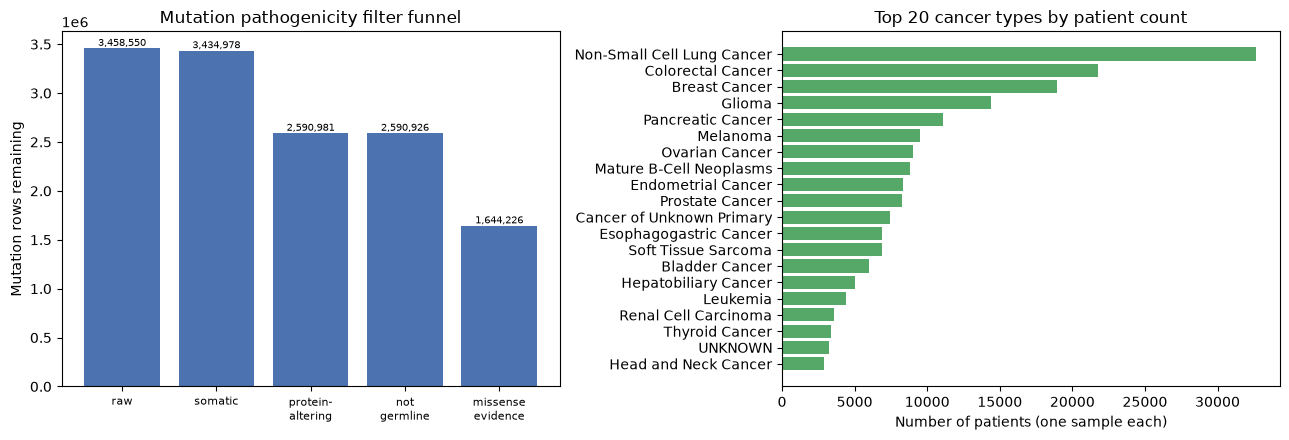

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

funnel = qc_summary["mutation_filter_funnel"]
FUNNEL_LABELS = {
    "raw_rows": "raw",
    "after_somatic_filter": "somatic",
    "after_protein_altering_filter": "protein-\naltering",
    "after_germline_af_filter": "not\ngermline",
    "after_missense_evidence_filter_FINAL_AM_hotspot_rule": "missense\nevidence",
}
funnel = {k: v for k, v in funnel.items() if k in FUNNEL_LABELS}  # drop the superseded old-rule step
steps = [FUNNEL_LABELS.get(k, k) for k in funnel.keys()]
values = list(funnel.values())
axes[0].bar(range(len(steps)), values, color="#4C72B0")
axes[0].set_xticks(range(len(steps)))
axes[0].set_xticklabels(steps, fontsize=8)
axes[0].set_ylabel("Mutation rows remaining")
axes[0].set_title("Mutation pathogenicity filter funnel")
for i, v in enumerate(values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)

top20 = cancer_type_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="#55A868")
axes[1].set_xlabel("Number of patients (one sample each)")
axes[1].set_title("Top 20 cancer types by patient count")

plt.tight_layout()
plt.show()

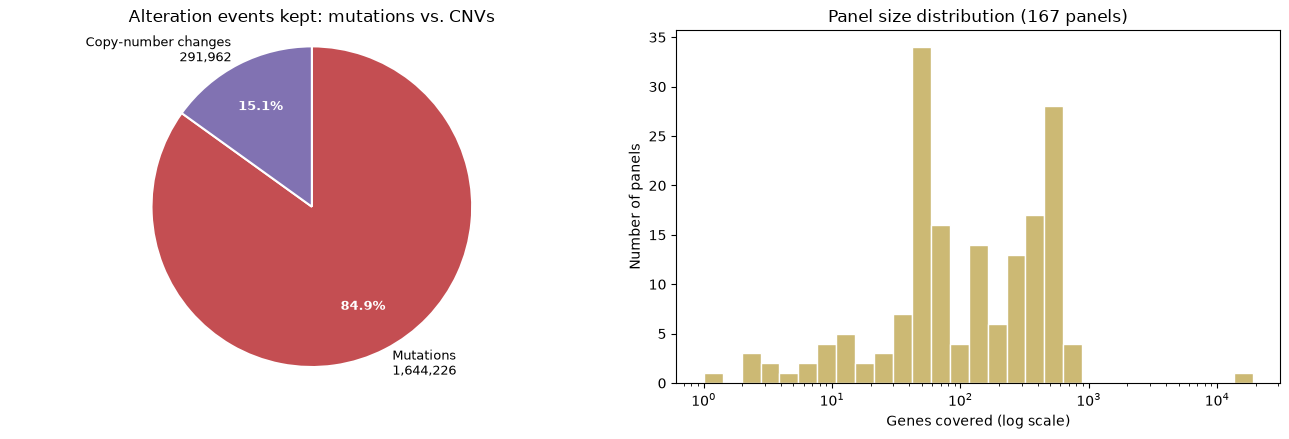

In [30]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

alt_counts = alterations["Alteration_Type"].value_counts()
alt_names = {"MUT": "Mutations", "CNV": "Copy-number changes"}
_, _, pct_labels = axes[0].pie(
    alt_counts.values, labels=[f"{alt_names.get(k, k)}\n{v:,}" for k, v in alt_counts.items()],
    colors=["#C44E52", "#8172B2"], autopct="%1.1f%%", startangle=90, counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 9}, pctdistance=0.7)
for t in pct_labels:                   # percentages sit inside the wedges
    t.set_color("white"); t.set_fontweight("bold")
axes[0].set_title("Alteration events kept: mutations vs. CNVs")
axes[0].axis("equal")

axes[1].hist(genes_per_panel, bins=np.logspace(np.log10(genes_per_panel.min()), np.log10(genes_per_panel.max()), 30),
             color="#CCB974", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Genes covered (log scale)")
axes[1].set_ylabel("Number of panels")
axes[1].set_title(f"Panel size distribution ({len(genes_per_panel)} panels)")

plt.tight_layout()
plt.show()

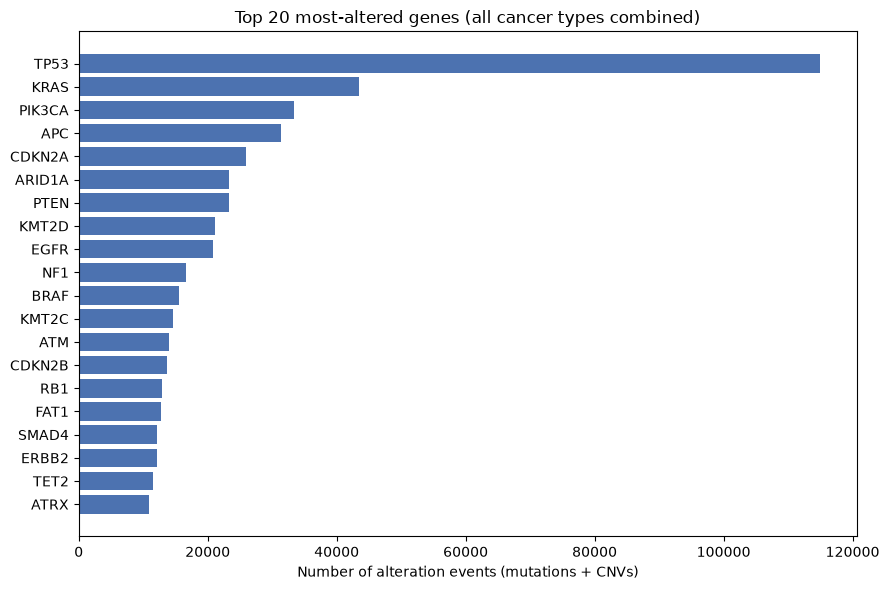

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
ranked_labels = [f"{gene}" for rank, gene in enumerate(top_genes.index, start=1)]
ax.barh(ranked_labels[::-1], top_genes.values[::-1], color="#4C72B0")
ax.set_xlabel("Number of alteration events (mutations + CNVs)")
ax.set_title("Top 20 most-altered genes (all cancer types combined)")
plt.tight_layout()
plt.show()

### 9b. Alterations per patient: the skew Phase 2 has to handle

For each of the 25 largest cancer types (one sample per patient), the number
of altered genes per patient: the bar is the middle 50% of patients, the
white dot the median, the tick the 90th percentile, and the red dot the
single most-altered patient.

The pattern is the same everywhere: **most patients carry a handful of
altered genes, a few carry dozens to hundreds** -- e.g. Melanoma median 5,
90th percentile 25, maximum 494; Glioma median 4, maximum 602. Those extreme
patients are mostly hypermutated tumours (broken DNA repair, UV, smoking).
A tumour with hundreds of alterations "co-occurs" with almost any gene by
sheer volume, so a test that treats every patient alike (Fisher's exact
test) reads that volume as biology. That is why Phase 2 compares each pair
against each patient's own alteration count, and why Section 1b records
hypermutation status (official TMB) for Phase 2 to use.

Counts are distinct altered genes on the patient's own panel, so a larger
panel can report more; the spread *within* a cancer type is the point here.


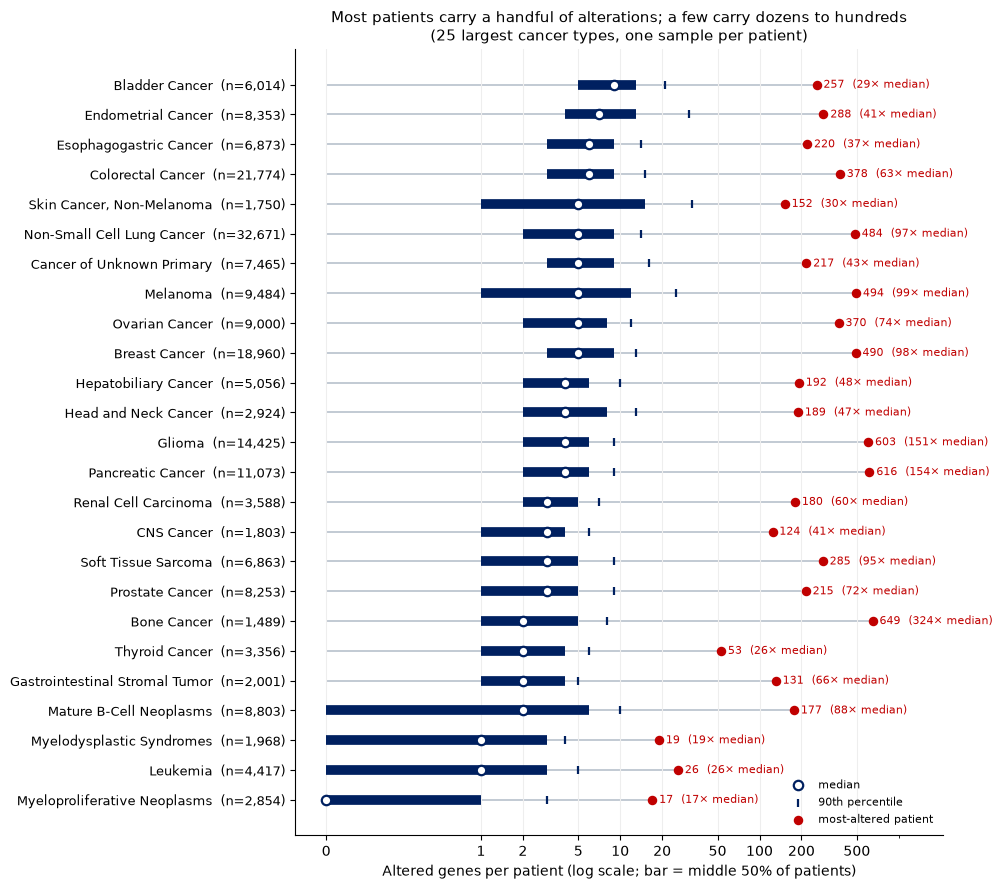

,patients,min,q25,median,q75,p90,max
CANCER_TYPE,,,,,,,
Myeloproliferative Neoplasms,2854,0,0.0,0.0,1.0,3.0,17
Leukemia,4417,0,0.0,1.0,3.0,5.0,26
Myelodysplastic Syndromes,1968,0,0.0,1.0,3.0,4.0,19
Mature B-Cell Neoplasms,8803,0,0.0,2.0,6.0,10.0,177
Gastrointestinal Stromal Tumor,2001,0,1.0,2.0,4.0,5.0,131
Thyroid Cancer,3356,0,1.0,2.0,4.0,6.0,53
Bone Cancer,1489,0,1.0,2.0,5.0,8.0,649
Prostate Cancer,8253,0,1.0,3.0,5.0,9.0,215
Soft Tissue Sarcoma,6863,0,1.0,3.0,5.0,9.0,285


In [32]:
# Alterations per patient, by cancer type: the skew Phase 2 has to handle.
# One representative sample per patient (Section 1c); a patient with no kept
# alteration counts as 0. Counts are distinct altered genes on the patient's
# own panel, so a larger panel can report more -- the within-cancer-type
# spread is the point here, not exact cross-type comparison.
import numpy as np
import matplotlib.pyplot as plt

rep = clinical.loc[clinical["IS_REPRESENTATIVE"], ["SAMPLE_ID", "CANCER_TYPE"]]
per_patient = (alterations[alterations["IS_REPRESENTATIVE"]]
               .groupby("Sample_ID")["Hugo_Symbol"].nunique())
burden = rep.assign(n_altered=rep["SAMPLE_ID"].map(per_patient).fillna(0).astype(int))

top_types = burden["CANCER_TYPE"].value_counts().drop("UNKNOWN", errors="ignore").head(25).index
b = burden[burden["CANCER_TYPE"].isin(top_types)]
burden_summary = (b.groupby("CANCER_TYPE")["n_altered"]
                  .agg(patients="size", min="min",
                       q25=lambda s: s.quantile(0.25), median="median",
                       q75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.90), max="max")
                  .sort_values("median"))

fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(burden_summary))
s = burden_summary
ax.hlines(y, s["min"], s["max"], color="#B8C1CC", lw=1.2, zorder=1)                     # full range
ax.hlines(y, s["q25"], s["q75"], color="#002060", lw=7, zorder=2)                        # middle 50%
ax.scatter(s["median"], y, s=46, color="white", edgecolor="#002060", lw=1.6, zorder=3, label="median")
ax.scatter(s["p90"], y, s=26, marker="|", color="#002060", lw=1.6, zorder=3, label="90th percentile")
ax.scatter(s["max"], y, s=34, color="#C00000", zorder=3, label="most-altered patient")
for yi, (mx, med) in enumerate(zip(s["max"], s["median"])):
    ax.text(mx * 1.12, yi, f"{mx:,.0f}  ({mx / max(med, 1):.0f}× median)", va="center", fontsize=8, color="#C00000")
ax.set_xscale("symlog", linthresh=1)
ax.set_xticks([0, 1, 2, 5, 10, 20, 50, 100, 200, 500])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlim(-0.2, s["max"].max() * 3.2)
ax.set_yticks(y)
ax.set_yticklabels([f"{ct}  (n={n:,})" for ct, n in zip(s.index, s["patients"])], fontsize=9)
ax.set_xlabel("Altered genes per patient (log scale; bar = middle 50% of patients)")
ax.set_title("Most patients carry a handful of alterations; a few carry dozens to hundreds\n"
             "(25 largest cancer types, one sample per patient)", fontsize=11)
ax.grid(axis="x", color="#EEEEEE", zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

burden_summary.round(1)


## Discussion

**The one idea this phase is built on:** when a gene shows nothing in a
patient's results, that can mean two completely different things -- *"we
looked and it was clean"* or *"we never looked"*. Different hospitals use
different test panels (167 of them), so this has to be tracked for every
gene in every patient, or every frequency we compute is silently skewed
toward whichever panels are most common.

**What we discovered along the way:** that same trap exists for copy-number
changes, and the panel metadata gets it wrong.

- `assay_information.txt` says 48 panels can detect copy-number changes.
- But for **20 of those panels, none of their patients appear in
  `data_CNA.txt` at all** -- the copy-number data was never released.
- Those ~99,000 patients were being scored "no copy-number change" when
  the truth was "never tested". In the worst-hit cancer types this
  understated copy-number frequencies by about **2x** (e.g. *CDKN2A*
  deletion in glioma: 17.4% -> 34.4% once fixed, in line with published
  figures of ~30-40%).
- The gene list itself (`genomic_information.txt`) is **correct** -- those
  panels really did sequence those genes for mutations. Only the
  copy-number claim was wrong.
- Fix: copy-number testability is now read from `data_CNA.txt` directly
  (`CNA_TESTED`, per patient), not trusted from the metadata. Only
  **172,874 of 271,837 patients (63.6%)** were ever tested for copy number.

**Copy-number changes now carry a label** (`CNV_Driver_Status`), because a
big chunk of chromosome being gained or lost sweeps up many neighbouring
genes that don't matter. Each call is checked against the gene's OncoKB
role: a tumour suppressor *lost* or an oncogene *gained* makes sense
(`Driver_Consistent`, 62.8%); the reverse is probably a bystander
(`Non_Consistent`, 22.6%); genes OncoKB has never reviewed are marked
`Unannotated` (14.6%) and kept. **`Non_Consistent` calls are dropped in
this phase** (85,254 of 377,216), mirroring the mutation pathogenicity
filter -- Phase 1's output is the driver-focused dataset. Checked before
dropping: the top dropped genes are all known neighbours of famous
amplicons/deletions, and the drop changed significance for only ~300 of
~20,000 gene pairs in Phase 2.

**Result:** 3,458,550 raw mutation rows -> 1,644,226 kept (rule: AlphaMissense
pathogenic, OR Polyphen+SIFT agree, OR a cancerhotspots match; germline cutoff
gnomAD AF <= 1e-3). 377,216 deep copy-number calls -> 291,962 kept after dropping
bystanders. Combined: 1,936,188 alteration events in 230,886 samples.
271,837 samples -> 227,696 patients (one sample each; 27,169 patients
had more than one). Hypermutation status (TMB >= 10 on panels >= 1 Mb):
28,602 samples hypermutated, 195,065 not, 48,170 unknown (small panel).
24,193 putative two-hit tumour-suppressor events. Gene lists: 173 genes
(pooled), 2,124 candidate genes per cancer type (>= 50 tested patients),
677 under the stricter >= 80% reference rule.

**Limitations:**
- Hypermutation status is unknown for patients on small panels (< 1 Mb):
  their TMB cannot be measured reliably, so Phase 2 leaves them out of its
  hypermutator re-test.
- The mutation filter is a good candidate rule that Jason approved, not a
  formally optimised cutoff.
- Shallow copy-number calls (-1) are excluded from the main alteration
  table and used only inside the two-hit feature. Jason confirmed this is
  fine for genes that also carry a mutation (the mutation call already
  marks the sample "altered" regardless of the deletion) -- but a shallow
  deletion **alone**, with no accompanying mutation, is still invisible to
  any table here. Relevant for haploinsufficient TSGs where one hit is
  already enough. Not yet resolved.
- ~~The two-hit feature is co-occurrence evidence -- we can't prove the
  deletion and mutation hit different copies of the gene (no phasing).~~
  **Resolved (Jason, see Section 5):** for a shallow deletion + detected
  mutation on the same gene, phasing isn't actually needed -- if one copy
  is deleted, a mutation detected there can only be on the surviving copy.
  Still open: a VAF-based consistency check hasn't been implemented yet.
- OncoKB is used at the *gene* level only (what role a gene has). Its
  *variant*-level annotation ("is this exact mutation cancer-causing")
  needs an API token and hasn't been used.
- Structural variants (`data_sv.txt`) are **deliberately excluded at this
  stage** -- supervisor decision. ~80% of patients are on SV-capable panels,
  so it isn't a coverage problem; the reasons are (a) SVs partly overlap
  what is already captured as SNV/CNV (e.g. an intragenic deletion shows up
  as both a deep deletion and an SV), so adding them risks double-counting
  the same event, and (b) the SNV+CNV relationship is already the
  complicated part worth getting right first -- many published studies
  stop at SNVs alone. If revisited: an SV is a two-gene event, so a partner
  rule is needed (count a partner only if it is on the patient's panel;
  drop the INTERGENIC/INTRAGENIC placeholders), and testability must be
  inferred at panel level since the file lists events, not tested patients
  (9 panels claim SV support but produce none).
- **Not yet addressed: panel-level technical batch effects.** Testability
  masking (this phase's core fix) only tracks *whether* a gene was in
  scope for a panel/sample -- it doesn't correct for panels differing in
  sequencing depth, variant-calling sensitivity, or tumor-purity cutoffs.
  Two patients with the same real mutation could have different odds of
  it being *called* depending on which panel processed them, independent
  of biology. Worth flagging before Phase 2 treats panel identity as a
  nuisance variable rather than a technical covariate.

**Open questions:** the 80% coverage cutoff and the 100-patient floor are
both provisional; whether blood cancers should be handled separately from
solid tumours is still unresolved.


## Next steps (Phase 2)

Use `alterations_long.parquet`, the two coverage tables and `clinical_tidy.parquet`
(one sample per patient, hypermutation status) to test every pair of
frequently altered genes within each cancer type, with a test that compares
each pair against each patient's own number of alterations (Phase 2
Section 4), rather than Fisher's exact test.
